<a href="https://colab.research.google.com/github/motiza345/starlight/blob/main/M22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%writefile m21_2_4_3_1_pipeline.py

Writing m21_2_4_3_1_pipeline.py


In [ ]:
from __future__ import annotations

import csv
import json
import os
from collections import deque
from dataclasses import dataclass
from enum import Enum
from typing import Any, Dict, List, Optional, Tuple

import numpy as np


# =====================================================================
# M21.2.4.3.1
# FINAL HARDENED CALIBRATION PIPELINE + M21.2.4.3.3 NPZ EXPORT
# =====================================================================

PIPELINE_VERSION = "M21.2.4.3.1-final-hardened-with-m21.2.4.3.3-export"

ARTIFACT_DIR = "artifacts/M21.2.4.3.1"
M2133_INPUT_NPZ = "artifacts/M21.2.4.3.1/M21_2_4_3_3_input.npz"

OPERATIONAL_EPS = 1e-4
FEATURE_DIM = 16

FEATURE_NAMES = [
    "R_abs_residual_t",
    "R_squared_residual_t",
    "R_mean_abs_residual_window",
    "R_residual_variance_window",
    "R_abs_residual_p90_window",
    "R_residual_zscore_t",
    "P_failure_run_length",
    "P_extreme_residual_fraction",
    "D_mean_probe_discrepancy",
    "D_max_probe_discrepancy",
    "C_probe_discrepancy_variance",
    "C_probe_coverage_fraction",
    "H_residual_anomaly_fraction",
    "H_mean_probe_discrepancy_history",
    "X_ambient_vibration",
    "X_input_energy",
]


# =====================================================================
# Environment
# =====================================================================

class EnvironmentTrack(str, Enum):
    KNOWN_VALID = "KNOWN_VALID"
    CAUSAL_BREAK = "CAUSAL_BREAK"
    REGIME_CHANGE_IN_SCOPE = "REGIME_CHANGE_IN_SCOPE"
    REGIME_CHANGE_OUT_OF_SCOPE = "REGIME_CHANGE_OUT_OF_SCOPE"
    FALSE_ALARM = "FALSE_ALARM"
    NOVEL_BUT_VALID = "NOVEL_BUT_VALID"
    NOVEL_AND_INVALID = "NOVEL_AND_INVALID"


@dataclass(frozen=True)
class AgentObservation:
    t: int
    x: float
    u: float
    y_obs: float
    y_pred_model: float
    observable_context_features: Dict[str, float]
    probe_observations: Dict[str, float]


class ScientificFrozenEnvironment:
    def __init__(
        self,
        track: EnvironmentTrack,
        noise_std: float = 0.05,
        probe_measurement_std: float = 0.01,
        seed: int = 42,
    ):
        self.track = track
        self.noise_std = float(noise_std)
        self.probe_measurement_std = float(probe_measurement_std)
        self.seed = int(seed)
        self.rng = np.random.RandomState(self.seed)
        self.t = 0

    def reset(self, seed: Optional[int] = None) -> "ScientificFrozenEnvironment":
        if seed is not None:
            self.seed = int(seed)
            self.rng = np.random.RandomState(self.seed)

        self.t = 0
        return self

    def step(
        self,
        x: float,
        u: float,
        probe_inputs: List[float],
    ) -> Tuple[AgentObservation, Any]:
        self.t += 1

        structurally_invalid = 0
        contextually_invalid = 0
        regime_changed = 0
        scope_violated = 0
        novel = 0
        active_mechanism = "M1"

        if self.track == EnvironmentTrack.CAUSAL_BREAK and self.t > 20:
            structurally_invalid = 1
            contextually_invalid = 1

        elif self.track == EnvironmentTrack.REGIME_CHANGE_IN_SCOPE and self.t > 20:
            regime_changed = 1

        elif (
            self.track == EnvironmentTrack.REGIME_CHANGE_OUT_OF_SCOPE
            and self.t > 20
        ):
            regime_changed = 1
            scope_violated = 1
            contextually_invalid = 1

        elif self.track == EnvironmentTrack.NOVEL_BUT_VALID and self.t > 20:
            novel = 1
            active_mechanism = "M_NEW"

        elif self.track == EnvironmentTrack.NOVEL_AND_INVALID and self.t > 20:
            novel = 1
            active_mechanism = "M_NEW"
            structurally_invalid = 1
            contextually_invalid = 1

        z = (
            self.rng.normal(0.0, 1.0)
            if self.noise_std > 0.0
            else 0.0
        )

        disturbance_scale = self.noise_std

        if (
            self.track == EnvironmentTrack.FALSE_ALARM
            and 18 <= self.t <= 22
        ):
            disturbance_scale = self.noise_std * 5.0

        shared_disturbance = z * disturbance_scale

        true_h1 = 0.6
        true_h4 = 0.5

        if self.track == EnvironmentTrack.CAUSAL_BREAK and self.t > 20:
            true_h4 = -0.5

        elif (
            self.track == EnvironmentTrack.REGIME_CHANGE_OUT_OF_SCOPE
            and self.t > 20
        ):
            true_h4 = 0.0

        elif (
            self.track == EnvironmentTrack.NOVEL_AND_INVALID
            and self.t > 20
        ):
            true_h4 = -0.3

        y_true = true_h1 * x + true_h4 * u + shared_disturbance
        y_pred = 0.6 * x + 0.5 * u

        probe_observations: Dict[str, float] = {}

        for probe_u in probe_inputs:
            p_noise = (
                self.rng.normal(0.0, self.probe_measurement_std)
                if self.probe_measurement_std > 0.0
                else 0.0
            )

            probe_observations[f"probe_{probe_u:.8f}"] = (
                true_h1 * x
                + true_h4 * probe_u
                + shared_disturbance
                + p_noise
            )

        observation = AgentObservation(
            t=self.t,
            x=float(x),
            u=float(u),
            y_obs=float(y_true),
            y_pred_model=float(y_pred),
            observable_context_features={
                "ambient_vibration": float(abs(shared_disturbance)),
                "input_energy": float(x**2 + u**2),
            },
            probe_observations=probe_observations,
        )

        ground_truth = type(
            "GroundTruth",
            (),
            {
                "is_structurally_invalid": structurally_invalid,
                "is_contextually_invalid": contextually_invalid,
                "is_regime_changed": regime_changed,
                "is_scope_violated": scope_violated,
                "is_novel": novel,
                "true_active_mechanism": active_mechanism,
            },
        )()

        return observation, ground_truth


# =====================================================================
# Frozen encoder
# =====================================================================

class ScientificFrozenEncoder:
    def __init__(self, window_size: int = 15):
        self.window_size = int(window_size)
        self.residual_history: deque = deque(maxlen=self.window_size)
        self.probe_disc_history: deque = deque(maxlen=self.window_size)
        self.failure_run_length = 0

    def reset(self) -> None:
        self.residual_history.clear()
        self.probe_disc_history.clear()
        self.failure_run_length = 0

    def encode(self, obs: AgentObservation) -> np.ndarray:
        residual_t = obs.y_obs - obs.y_pred_model
        self.residual_history.append(residual_t)

        residuals = np.asarray(self.residual_history, dtype=float)
        abs_residuals = np.abs(residuals)

        mean_residual = float(np.mean(residuals))
        residual_std = float(np.std(residuals) + 1e-6)
        residual_z = float((residual_t - mean_residual) / residual_std)

        residual_features = [
            float(abs_residuals[-1]),
            float(residual_t**2),
            float(np.mean(abs_residuals)),
            float(np.var(residuals)) if len(residuals) > 1 else 0.0,
            float(np.percentile(abs_residuals, 90)),
            residual_z,
        ]

        if abs(residual_z) > 2.0:
            self.failure_run_length += 1
        else:
            self.failure_run_length = 0

        persistence_features = [
            float(self.failure_run_length),
            float(
                np.mean(
                    abs_residuals
                    > (np.mean(abs_residuals) + 2.0 * residual_std)
                )
            ),
        ]

        causal_discrepancies = []

        for probe_key, probe_value in obs.probe_observations.items():
            probe_u = float(probe_key.split("_", maxsplit=1)[1])

            expected_probe_delta = (
                (0.6 * obs.x + 0.5 * probe_u) - obs.y_pred_model
            )
            observed_probe_delta = probe_value - obs.y_obs

            causal_discrepancies.append(
                abs(observed_probe_delta - expected_probe_delta)
            )

        mean_probe_disc = (
            float(np.mean(causal_discrepancies))
            if causal_discrepancies
            else 0.0
        )

        max_probe_disc = (
            float(np.max(causal_discrepancies))
            if causal_discrepancies
            else 0.0
        )

        self.probe_disc_history.append(mean_probe_disc)

        discrepancy_features = [
            mean_probe_disc,
            max_probe_disc,
        ]

        causal_structure_features = [
            float(np.var(causal_discrepancies))
            if len(causal_discrepancies) > 1
            else 0.0,
            float(len(causal_discrepancies)) / 5.0,
        ]

        historical_features = [
            float(
                np.mean(
                    abs_residuals
                    > (np.mean(abs_residuals) + 1.5 * residual_std)
                )
            ),
            float(np.mean(self.probe_disc_history)),
        ]

        context_features = [
            float(
                obs.observable_context_features.get(
                    "ambient_vibration",
                    0.0,
                )
            ),
            float(
                obs.observable_context_features.get(
                    "input_energy",
                    0.0,
                )
            ),
        ]

        phi = np.asarray(
            residual_features
            + persistence_features
            + discrepancy_features
            + causal_structure_features
            + historical_features
            + context_features,
            dtype=float,
        )

        phi = np.nan_to_num(
            phi,
            nan=0.0,
            posinf=1e6,
            neginf=-1e6,
        )

        assert phi.shape == (FEATURE_DIM,)
        return phi


# =====================================================================
# Logistic invalidity estimator
# =====================================================================

class SelfModelInvalidityEstimator:
    def __init__(
        self,
        feature_dim: int,
        l2_reg: float = 0.01,
    ):
        self.feature_dim = int(feature_dim)
        self.l2_reg = float(l2_reg)

        self.weights = np.zeros(self.feature_dim, dtype=float)
        self.bias = 0.0

        self.mean_X: Optional[np.ndarray] = None
        self.std_X: Optional[np.ndarray] = None
        self.is_trained = False

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        z = np.clip(z, -500.0, 500.0)
        return 1.0 / (1.0 + np.exp(-z))

    def fit(
        self,
        X: np.ndarray,
        y: np.ndarray,
        epochs: int = 800,
        lr: float = 0.1,
    ) -> None:
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1)

        if X.ndim != 2 or X.shape[1] != self.feature_dim:
            raise ValueError("Invalid X shape.")

        if len(X) == 0 or len(X) != len(y):
            raise ValueError("Empty or inconsistent training data.")

        if not np.all(np.isin(y, [0.0, 1.0])):
            raise ValueError("Training labels must be binary.")

        self.mean_X = np.mean(X, axis=0)
        self.std_X = np.std(X, axis=0) + 1e-6

        X_norm = (X - self.mean_X) / self.std_X

        for _ in range(int(epochs)):
            logits = X_norm @ self.weights + self.bias
            probabilities = self._sigmoid(logits)
            error = probabilities - y

            gradient_w = (
                (X_norm.T @ error) / len(X_norm)
                + self.l2_reg * self.weights
            )
            gradient_b = float(np.mean(error))

            self.weights -= float(lr) * gradient_w
            self.bias -= float(lr) * gradient_b

        self.is_trained = True

    def predict_logit(self, X: np.ndarray) -> np.ndarray:
        if (
            not self.is_trained
            or self.mean_X is None
            or self.std_X is None
        ):
            raise RuntimeError("Estimator must be fitted first.")

        X = np.asarray(X, dtype=float)

        if X.ndim == 1:
            X = X.reshape(1, -1)

        X_norm = (X - self.mean_X) / self.std_X
        return X_norm @ self.weights + self.bias

    def predict_raw_probability(self, X: np.ndarray) -> np.ndarray:
        return self._sigmoid(self.predict_logit(X))


# =====================================================================
# Exact weighted PAVA isotonic calibrator
# =====================================================================

class IsotonicCalibrator:
    def __init__(self):
        self.block_left_edges: Optional[np.ndarray] = None
        self.block_right_edges: Optional[np.ndarray] = None
        self.block_weights: Optional[np.ndarray] = None
        self.block_positive_masses: Optional[np.ndarray] = None
        self.block_values: Optional[np.ndarray] = None
        self.is_fitted = False

    def fit(
        self,
        scores: np.ndarray,
        labels: np.ndarray,
    ) -> "IsotonicCalibrator":
        scores = np.asarray(scores, dtype=float).reshape(-1)
        labels = np.asarray(labels, dtype=float).reshape(-1)

        if len(scores) == 0:
            raise ValueError("Calibration set is empty.")

        if len(scores) != len(labels):
            raise ValueError("scores and labels length mismatch.")

        if not np.all(np.isfinite(scores)):
            raise ValueError("Scores must be finite.")

        if not np.all(np.isin(labels, [0.0, 1.0])):
            raise ValueError("Labels must be binary.")

        order = np.argsort(scores, kind="mergesort")
        scores = scores[order]
        labels = labels[order]

        unique_scores, inverse = np.unique(
            scores,
            return_inverse=True,
        )

        grouped_weight = np.zeros(len(unique_scores), dtype=float)
        grouped_positive_mass = np.zeros(len(unique_scores), dtype=float)

        np.add.at(grouped_weight, inverse, 1.0)
        np.add.at(grouped_positive_mass, inverse, labels)

        blocks: List[Dict[str, float]] = []

        for i, score in enumerate(unique_scores):
            blocks.append(
                {
                    "left": float(score),
                    "right": float(score),
                    "weight": float(grouped_weight[i]),
                    "positive_mass": float(grouped_positive_mass[i]),
                }
            )

            while len(blocks) >= 2:
                left = blocks[-2]
                right = blocks[-1]

                left_value = left["positive_mass"] / left["weight"]
                right_value = right["positive_mass"] / right["weight"]

                if left_value <= right_value:
                    break

                blocks[-2:] = [
                    {
                        "left": left["left"],
                        "right": right["right"],
                        "weight": left["weight"] + right["weight"],
                        "positive_mass": (
                            left["positive_mass"]
                            + right["positive_mass"]
                        ),
                    }
                ]

        self.block_left_edges = np.asarray(
            [block["left"] for block in blocks],
            dtype=float,
        )
        self.block_right_edges = np.asarray(
            [block["right"] for block in blocks],
            dtype=float,
        )
        self.block_weights = np.asarray(
            [block["weight"] for block in blocks],
            dtype=float,
        )
        self.block_positive_masses = np.asarray(
            [block["positive_mass"] for block in blocks],
            dtype=float,
        )
        self.block_values = (
            self.block_positive_masses / self.block_weights
        )
        self.is_fitted = True

        assert np.all(np.diff(self.block_values) >= -1e-12)

        return self

    def calibrate(self, scores: np.ndarray) -> np.ndarray:
        if not self.is_fitted:
            raise RuntimeError("Calibrator is not fitted.")

        assert self.block_right_edges is not None
        assert self.block_values is not None

        scores = np.asarray(scores, dtype=float)

        if not np.all(np.isfinite(scores)):
            raise ValueError("Scores must be finite.")

        indices = np.searchsorted(
            self.block_right_edges,
            scores,
            side="left",
        )
        indices = np.clip(indices, 0, len(self.block_values) - 1)

        return self.block_values[indices]


# =====================================================================
# Data collection
# =====================================================================

def collect_episode_track_data(
    tracks: List[EnvironmentTrack],
    num_episodes: int,
    seed_start: int,
) -> Dict[str, List[Dict[str, Any]]]:
    episodes_by_track: Dict[str, List[Dict[str, Any]]] = {}
    current_seed = int(seed_start)

    for track in tracks:
        track_episodes: List[Dict[str, Any]] = []

        for episode_index in range(int(num_episodes)):
            env = ScientificFrozenEnvironment(
                track=track,
                noise_std=0.05,
                probe_measurement_std=0.01,
                seed=current_seed,
            )
            encoder = ScientificFrozenEncoder(window_size=15)

            env.reset()
            encoder.reset()

            x_frequency = env.rng.uniform(0.05, 0.15)

            X_rows = []
            y_rows = []
            t_rows = []

            for step in range(40):
                x = np.sin(step * x_frequency)
                u = np.cos(step * x_frequency)

                obs, gt = env.step(
                    x=float(x),
                    u=float(u),
                    probe_inputs=[float(u + 0.2)],
                )

                X_rows.append(encoder.encode(obs))
                y_rows.append(gt.is_contextually_invalid)
                t_rows.append(obs.t)

            track_episodes.append(
                {
                    "X": np.asarray(X_rows, dtype=float),
                    "y": np.asarray(y_rows, dtype=int),
                    "t": np.asarray(t_rows, dtype=int),
                    "seed": int(current_seed),
                    "episode_id_within_track": int(episode_index),
                }
            )

            current_seed += 1

        episodes_by_track[track.value] = track_episodes

    return episodes_by_track


def flatten_split(
    episodes_by_track: Dict[str, List[Dict[str, Any]]],
    split_name: str,
) -> Dict[str, np.ndarray]:
    X_parts = []
    y_parts = []
    track_parts = []
    episode_parts = []
    timestep_parts = []

    for track_name, episodes in episodes_by_track.items():
        for episode in episodes:
            X_episode = np.asarray(episode["X"], dtype=float)
            y_episode = np.asarray(episode["y"], dtype=int)
            t_episode = np.asarray(episode["t"], dtype=int)

            episode_seed = int(episode["seed"])
            episode_index = int(episode["episode_id_within_track"])

            stable_episode_id = (
                f"{split_name}"
                f"__{track_name}"
                f"__seed_{episode_seed}"
                f"__episode_{episode_index:03d}"
            )

            n = len(y_episode)

            X_parts.append(X_episode)
            y_parts.append(y_episode)
            track_parts.append(np.full(n, track_name, dtype=str))
            episode_parts.append(np.full(n, stable_episode_id, dtype=str))
            timestep_parts.append(t_episode)

    return {
        "X": np.concatenate(X_parts),
        "y": np.concatenate(y_parts).astype(int),
        "track": np.concatenate(track_parts).astype(str),
        "episode_id": np.concatenate(episode_parts).astype(str),
        "timestep": np.concatenate(timestep_parts).astype(int),
    }


# =====================================================================
# Utilities
# =====================================================================

def brier_score(y: np.ndarray, p: np.ndarray) -> float:
    y = np.asarray(y, dtype=float)
    p = np.asarray(p, dtype=float)
    return float(np.mean((y - p) ** 2))


def binary_logloss(
    y: np.ndarray,
    p: np.ndarray,
    eps: float = 1e-12,
) -> float:
    y = np.asarray(y, dtype=float)
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0 - eps)

    return float(
        -np.mean(
            y * np.log(p)
            + (1.0 - y) * np.log(1.0 - p)
        )
    )


def save_json(path: str, payload: Any) -> None:
    with open(path, "w", encoding="utf-8") as file:
        json.dump(payload, file, indent=2, ensure_ascii=False)


def save_csv(
    path: str,
    rows: List[Dict[str, Any]],
    fieldnames: List[str],
) -> None:
    with open(path, "w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


# =====================================================================
# Main
# =====================================================================

def main() -> None:
    os.makedirs(ARTIFACT_DIR, exist_ok=True)

    print("=" * 72)
    print("M21.2.4.3.1 FINAL PIPELINE + M21.2.4.3.3 NPZ EXPORT")
    print("=" * 72)

    train_tracks = [
        EnvironmentTrack.KNOWN_VALID,
        EnvironmentTrack.CAUSAL_BREAK,
        EnvironmentTrack.FALSE_ALARM,
    ]

    calibration_tracks = [
        EnvironmentTrack.KNOWN_VALID,
        EnvironmentTrack.CAUSAL_BREAK,
        EnvironmentTrack.FALSE_ALARM,
    ]

    final_test_tracks = [
        EnvironmentTrack.KNOWN_VALID,
        EnvironmentTrack.FALSE_ALARM,
        EnvironmentTrack.REGIME_CHANGE_IN_SCOPE,
        EnvironmentTrack.REGIME_CHANGE_OUT_OF_SCOPE,
        EnvironmentTrack.NOVEL_BUT_VALID,
        EnvironmentTrack.NOVEL_AND_INVALID,
    ]

    train_episodes = collect_episode_track_data(
        tracks=train_tracks,
        num_episodes=12,
        seed_start=100,
    )

    calibration_episodes = collect_episode_track_data(
        tracks=calibration_tracks,
        num_episodes=8,
        seed_start=400,
    )

    final_test_episodes = collect_episode_track_data(
        tracks=final_test_tracks,
        num_episodes=10,
        seed_start=800,
    )

    train_data = flatten_split(train_episodes, split_name="train")
    calibration_data = flatten_split(
        calibration_episodes,
        split_name="calibration",
    )
    test_data = flatten_split(
        final_test_episodes,
        split_name="final_test",
    )

    train_episode_ids = set(train_data["episode_id"].tolist())
    calibration_episode_ids = set(
        calibration_data["episode_id"].tolist()
    )
    test_episode_ids = set(test_data["episode_id"].tolist())

    assert not train_episode_ids.intersection(calibration_episode_ids)
    assert not train_episode_ids.intersection(test_episode_ids)
    assert not calibration_episode_ids.intersection(test_episode_ids)

    print("Episode-disjoint split audit: PASS")
    print(
        f"Train:       {len(train_data['y'])} samples | "
        f"{len(train_episode_ids)} episodes"
    )
    print(
        f"Calibration: {len(calibration_data['y'])} samples | "
        f"{len(calibration_episode_ids)} episodes"
    )
    print(
        f"Final test:  {len(test_data['y'])} samples | "
        f"{len(test_episode_ids)} episodes"
    )

    estimator = SelfModelInvalidityEstimator(
        feature_dim=FEATURE_DIM,
        l2_reg=0.01,
    )

    estimator.fit(
        train_data["X"],
        train_data["y"],
        epochs=800,
        lr=0.1,
    )

    raw_probability_calibration = estimator.predict_raw_probability(
        calibration_data["X"]
    )

    raw_probability_test = estimator.predict_raw_probability(
        test_data["X"]
    )

    raw_logit_test = estimator.predict_logit(test_data["X"])

    assert np.all(np.isfinite(raw_probability_calibration))
    assert np.all(np.isfinite(raw_probability_test))

    assert np.all(
        (raw_probability_calibration >= 0.0)
        & (raw_probability_calibration <= 1.0)
    )

    assert np.all(
        (raw_probability_test >= 0.0)
        & (raw_probability_test <= 1.0)
    )

    # -----------------------------------------------------------------
    # EXACTLY EIGHT NPZ KEYS FOR M21.2.4.3.3
    # -----------------------------------------------------------------

    np.savez_compressed(
        M2133_INPUT_NPZ,
        raw_probability_calibration=raw_probability_calibration,
        y_calibration=calibration_data["y"],
        track_calibration=calibration_data["track"],
        episode_id_calibration=calibration_data["episode_id"],
        raw_probability_test=raw_probability_test,
        y_test=test_data["y"],
        track_test=test_data["track"],
        episode_id_test=test_data["episode_id"],
    )

    saved_npz = np.load(M2133_INPUT_NPZ, allow_pickle=False)

    required_keys = {
        "raw_probability_calibration",
        "y_calibration",
        "track_calibration",
        "episode_id_calibration",
        "raw_probability_test",
        "y_test",
        "track_test",
        "episode_id_test",
    }

    assert set(saved_npz.files) == required_keys, (
        "NPZ key contract failed.\n"
        f"Expected: {sorted(required_keys)}\n"
        f"Found: {sorted(saved_npz.files)}"
    )

    print("\nM21.2.4.3.3 NPZ export: PASS")
    print("NPZ path:", M2133_INPUT_NPZ)
    print("NPZ keys:", sorted(saved_npz.files))

    # -----------------------------------------------------------------
    # Existing isotonic calibration artifacts
    # -----------------------------------------------------------------

    calibrator = IsotonicCalibrator().fit(
        raw_probability_calibration,
        calibration_data["y"],
    )

    isotonic_probability_test = calibrator.calibrate(
        raw_probability_test
    )

    operational_probability_test = np.clip(
        isotonic_probability_test,
        OPERATIONAL_EPS,
        1.0 - OPERATIONAL_EPS,
    )

    np.savez_compressed(
        os.path.join(ARTIFACT_DIR, "estimator_parameters.npz"),
        weights=estimator.weights,
        bias=np.asarray([estimator.bias], dtype=float),
        mean_X=estimator.mean_X,
        std_X=estimator.std_X,
        feature_names=np.asarray(FEATURE_NAMES, dtype=str),
    )

    np.savez_compressed(
        os.path.join(ARTIFACT_DIR, "isotonic_calibrator.npz"),
        left_edges=calibrator.block_left_edges,
        right_edges=calibrator.block_right_edges,
        weights=calibrator.block_weights,
        positive_masses=calibrator.block_positive_masses,
        values=calibrator.block_values,
    )

    prediction_rows = []

    for i in range(len(test_data["y"])):
        prediction_rows.append(
            {
                "track": str(test_data["track"][i]),
                "episode_id": str(test_data["episode_id"][i]),
                "timestep": int(test_data["timestep"][i]),
                "y_true": int(test_data["y"][i]),
                "raw_logit": float(raw_logit_test[i]),
                "raw_probability": float(raw_probability_test[i]),
                "isotonic_probability": float(
                    isotonic_probability_test[i]
                ),
                "operational_probability": float(
                    operational_probability_test[i]
                ),
            }
        )

    save_csv(
        os.path.join(ARTIFACT_DIR, "final_predictions.csv"),
        prediction_rows,
        fieldnames=list(prediction_rows[0].keys()),
    )

    manifest = {
        "pipeline_version": PIPELINE_VERSION,
        "feature_dim": FEATURE_DIM,
        "feature_names": FEATURE_NAMES,
        "train_tracks": [x.value for x in train_tracks],
        "calibration_tracks": [x.value for x in calibration_tracks],
        "final_test_tracks": [x.value for x in final_test_tracks],
        "train_episodes": 36,
        "calibration_episodes": 24,
        "final_test_episodes": 60,
        "steps_per_episode": 40,
        "episode_disjoint_splits": True,
        "m2133_input_npz": M2133_INPUT_NPZ,
        "m2133_npz_exact_key_count": 8,
        "m2133_npz_keys": sorted(required_keys),
    }

    save_json(
        os.path.join(ARTIFACT_DIR, "split_manifest.json"),
        manifest,
    )

    summary = {
        "raw_brier_final_test": brier_score(
            test_data["y"],
            raw_probability_test,
        ),
        "raw_logloss_final_test": binary_logloss(
            test_data["y"],
            raw_probability_test,
        ),
        "isotonic_brier_final_test": brier_score(
            test_data["y"],
            isotonic_probability_test,
        ),
        "isotonic_logloss_final_test": binary_logloss(
            test_data["y"],
            isotonic_probability_test,
        ),
        "n_isotonic_blocks": int(len(calibrator.block_values)),
        "n_exact_p0_final_test": int(
            np.sum(isotonic_probability_test == 0.0)
        ),
        "n_exact_p1_final_test": int(
            np.sum(isotonic_probability_test == 1.0)
        ),
    }

    save_json(
        os.path.join(ARTIFACT_DIR, "pipeline_summary.json"),
        summary,
    )

    print("\n--- PIPELINE SUMMARY ---")
    print(json.dumps(summary, indent=2))
    print("\nAll artifacts saved in:", ARTIFACT_DIR)


if __name__ == "__main__":
    main()

M21.2.4.3.1 FINAL PIPELINE + M21.2.4.3.3 NPZ EXPORT
Episode-disjoint split audit: PASS
Train:       1440 samples | 1 episodes
Calibration: 960 samples | 1 episodes
Final test:  2400 samples | 1 episodes

M21.2.4.3.3 NPZ export: PASS
NPZ path: artifacts/M21.2.4.3.1/M21_2_4_3_3_input.npz
NPZ keys: ['episode_id_calibration', 'episode_id_test', 'raw_probability_calibration', 'raw_probability_test', 'track_calibration', 'track_test', 'y_calibration', 'y_test']

--- PIPELINE SUMMARY ---
{
  "raw_brier_final_test": 0.009430540945645277,
  "raw_logloss_final_test": 0.044149829615736845,
  "isotonic_brier_final_test": 0.0004166666666666667,
  "isotonic_logloss_final_test": 0.011512934683455123,
  "n_isotonic_blocks": 960,
  "n_exact_p0_final_test": 1999,
  "n_exact_p1_final_test": 401
}

All artifacts saved in: artifacts/M21.2.4.3.1


In [ ]:
!python m21_2_4_3_1_pipeline.py

In [ ]:
%%writefile m21_2_4_3_3_audit.py

Writing m21_2_4_3_3_audit.py


In [ ]:
from __future__ import annotations

import csv
import hashlib
import json
import os
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt


# =====================================================================
# M21.2.4.3.3
# CALIBRATION STRESS & SUPPORT AUDIT
# =====================================================================

AUDIT_VERSION = "M21.2.4.3.3-calibration-stress-support-audit"

INPUT_NPZ = "artifacts/M21.2.4.3.1/M21_2_4_3_3_input.npz"
OUTPUT_DIR = "artifacts/M21.2.4.3.3"

N_BOOTSTRAP = 2000
N_RELIABILITY_BINS = 10

# کوچک است؛ هدف، آزمون پایداری mapping در برابر perturbation محدود است.
PERTURBATION_SCALES = [0.0, 1e-6, 1e-5, 1e-4, 1e-3]

REQUIRED_KEYS = {
    "raw_probability_calibration",
    "y_calibration",
    "track_calibration",
    "episode_id_calibration",
    "raw_probability_test",
    "y_test",
    "track_test",
    "episode_id_test",
}


# =====================================================================
# Stable deterministic seed
# =====================================================================

def stable_seed(*parts: Any) -> int:
    payload = "||".join(map(str, parts)).encode("utf-8")
    digest = hashlib.sha256(payload).digest()
    return int.from_bytes(digest[:8], byteorder="little") % (2**32 - 1)


# =====================================================================
# PAVA
# =====================================================================

class IsotonicCalibrator:
    def __init__(self):
        self.left_edges: Optional[np.ndarray] = None
        self.right_edges: Optional[np.ndarray] = None
        self.weights: Optional[np.ndarray] = None
        self.positive_masses: Optional[np.ndarray] = None
        self.values: Optional[np.ndarray] = None
        self.is_fitted = False

    def fit(
        self,
        scores: np.ndarray,
        labels: np.ndarray,
    ) -> "IsotonicCalibrator":
        scores = np.asarray(scores, dtype=float).reshape(-1)
        labels = np.asarray(labels, dtype=float).reshape(-1)

        if len(scores) == 0:
            raise ValueError("Calibration split is empty.")

        if len(scores) != len(labels):
            raise ValueError("scores/labels length mismatch.")

        if not np.all(np.isfinite(scores)):
            raise ValueError("Non-finite calibration scores.")

        if not np.all(np.isin(labels, [0.0, 1.0])):
            raise ValueError("Calibration labels must be binary.")

        order = np.argsort(scores, kind="mergesort")
        scores = scores[order]
        labels = labels[order]

        unique_scores, inverse = np.unique(
            scores,
            return_inverse=True,
        )

        grouped_weight = np.zeros(len(unique_scores), dtype=float)
        grouped_positive = np.zeros(len(unique_scores), dtype=float)

        np.add.at(grouped_weight, inverse, 1.0)
        np.add.at(grouped_positive, inverse, labels)

        blocks: List[Dict[str, float]] = []

        for i, score in enumerate(unique_scores):
            blocks.append(
                {
                    "left": float(score),
                    "right": float(score),
                    "weight": float(grouped_weight[i]),
                    "positive": float(grouped_positive[i]),
                }
            )

            while len(blocks) >= 2:
                b_left = blocks[-2]
                b_right = blocks[-1]

                mean_left = b_left["positive"] / b_left["weight"]
                mean_right = b_right["positive"] / b_right["weight"]

                if mean_left <= mean_right:
                    break

                blocks[-2:] = [
                    {
                        "left": b_left["left"],
                        "right": b_right["right"],
                        "weight": b_left["weight"] + b_right["weight"],
                        "positive": (
                            b_left["positive"] + b_right["positive"]
                        ),
                    }
                ]

        self.left_edges = np.asarray(
            [b["left"] for b in blocks],
            dtype=float,
        )
        self.right_edges = np.asarray(
            [b["right"] for b in blocks],
            dtype=float,
        )
        self.weights = np.asarray(
            [b["weight"] for b in blocks],
            dtype=float,
        )
        self.positive_masses = np.asarray(
            [b["positive"] for b in blocks],
            dtype=float,
        )
        self.values = self.positive_masses / self.weights
        self.is_fitted = True

        assert np.all(np.diff(self.values) >= -1e-12)
        return self

    def calibrate(self, scores: np.ndarray) -> np.ndarray:
        if not self.is_fitted:
            raise RuntimeError("Calibrator not fitted.")

        assert self.right_edges is not None
        assert self.values is not None

        scores = np.asarray(scores, dtype=float)

        if not np.all(np.isfinite(scores)):
            raise ValueError("Prediction scores must be finite.")

        idx = np.searchsorted(
            self.right_edges,
            scores,
            side="left",
        )

        idx = np.clip(idx, 0, len(self.values) - 1)
        return self.values[idx]

    def block_index(self, scores: np.ndarray) -> np.ndarray:
        assert self.right_edges is not None

        scores = np.asarray(scores, dtype=float)

        idx = np.searchsorted(
            self.right_edges,
            scores,
            side="left",
        )

        return np.clip(idx, 0, len(self.right_edges) - 1)


# =====================================================================
# Metrics
# =====================================================================

def brier_score(y: np.ndarray, p: np.ndarray) -> float:
    y = np.asarray(y, dtype=float)
    p = np.asarray(p, dtype=float)
    return float(np.mean((y - p) ** 2))


def logloss(
    y: np.ndarray,
    p: np.ndarray,
    eps: float = 1e-12,
) -> float:
    y = np.asarray(y, dtype=float)
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0 - eps)

    return float(
        -np.mean(y * np.log(p) + (1.0 - y) * np.log(1.0 - p))
    )


def reliability_table(
    y: np.ndarray,
    p: np.ndarray,
    n_bins: int = N_RELIABILITY_BINS,
) -> Tuple[List[Dict[str, Any]], float]:
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    rows = []
    ece = 0.0

    for i in range(n_bins):
        lo = float(edges[i])
        hi = float(edges[i + 1])

        if i == n_bins - 1:
            mask = (p >= lo) & (p <= hi)
            label = f"[{lo:.1f}, {hi:.1f}]"
        else:
            mask = (p >= lo) & (p < hi)
            label = f"[{lo:.1f}, {hi:.1f})"

        count = int(np.sum(mask))

        if count == 0:
            rows.append(
                {
                    "bin": label,
                    "count": 0,
                    "mean_probability": None,
                    "empirical_rate": None,
                    "absolute_gap": None,
                }
            )
            continue

        mean_p = float(np.mean(p[mask]))
        empirical = float(np.mean(y[mask]))
        gap = abs(empirical - mean_p)

        ece += (count / len(y)) * gap

        rows.append(
            {
                "bin": label,
                "count": count,
                "mean_probability": mean_p,
                "empirical_rate": empirical,
                "absolute_gap": float(gap),
            }
        )

    return rows, float(ece)


def episode_bootstrap_brier(
    y: np.ndarray,
    p: np.ndarray,
    episode_id: np.ndarray,
    n_bootstrap: int,
) -> Dict[str, float]:
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    episode_id = np.asarray(episode_id, dtype=str)

    unique_episodes = np.unique(episode_id)
    rng = np.random.default_rng(
        stable_seed("episode-bootstrap-brier", n_bootstrap)
    )

    values = []

    for _ in range(n_bootstrap):
        sampled = rng.choice(
            unique_episodes,
            size=len(unique_episodes),
            replace=True,
        )

        indices = np.concatenate(
            [
                np.flatnonzero(episode_id == ep)
                for ep in sampled
            ]
        )

        values.append(brier_score(y[indices], p[indices]))

    return {
        "observed": brier_score(y, p),
        "ci95_low": float(np.percentile(values, 2.5)),
        "ci95_high": float(np.percentile(values, 97.5)),
    }


# =====================================================================
# IO
# =====================================================================

def save_json(path: str, payload: Any) -> None:
    with open(path, "w", encoding="utf-8") as file:
        json.dump(payload, file, indent=2, ensure_ascii=False)


def save_csv(
    path: str,
    rows: List[Dict[str, Any]],
    fieldnames: List[str],
) -> None:
    with open(path, "w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


# =====================================================================
# Plots
# =====================================================================

def plot_support_distribution(
    weights: np.ndarray,
    output_path: str,
) -> None:
    plt.figure(figsize=(8, 5))
    plt.hist(weights, bins=min(40, max(5, len(weights))), edgecolor="black")
    plt.xlabel("Calibration support per isotonic block")
    plt.ylabel("Number of blocks")
    plt.title("Isotonic Block Support Distribution")
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.close()


def plot_local_support_distribution(
    local_support: np.ndarray,
    output_path: str,
) -> None:
    plt.figure(figsize=(8, 5))
    plt.hist(
        local_support,
        bins=min(40, max(5, len(np.unique(local_support)))),
        edgecolor="black",
    )
    plt.xlabel("Calibration support of mapped test block")
    plt.ylabel("Number of test samples")
    plt.title("Local Calibration Support for Final-Test Samples")
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.close()


def plot_certainty_status(
    calibrated_p: np.ndarray,
    local_support: np.ndarray,
    output_path: str,
) -> None:
    status = np.full(len(calibrated_p), "INTERIOR", dtype=object)

    status[calibrated_p == 0.0] = "EXACT_ZERO"
    status[calibrated_p == 1.0] = "EXACT_ONE"

    labels = [
        "INTERIOR",
        "EXACT_ZERO",
        "EXACT_ONE",
    ]

    counts = [int(np.sum(status == label)) for label in labels]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, counts)
    plt.ylabel("Final-test samples")
    plt.title("Certainty-Status Audit (not semantic certainty)")
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.close()


def plot_reliability(
    rows: List[Dict[str, Any]],
    output_path: str,
) -> None:
    x = []
    y = []

    for row in rows:
        if row["count"] > 0:
            x.append(row["mean_probability"])
            y.append(row["empirical_rate"])

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], "--", label="Ideal")
    plt.scatter(x, y, s=45, label="Observed bins")
    plt.xlabel("Mean calibrated probability")
    plt.ylabel("Empirical invalidity rate")
    plt.title("Reliability Diagram: Final Test")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=160)
    plt.close()


# =====================================================================
# Stress audits
# =====================================================================

def score_perturbation_audit(
    calibrator: IsotonicCalibrator,
    raw_test: np.ndarray,
    base_p: np.ndarray,
) -> List[Dict[str, Any]]:
    rows = []

    for scale in PERTURBATION_SCALES:
        rng = np.random.default_rng(
            stable_seed("score-perturbation", scale)
        )

        if scale == 0.0:
            perturbed_scores = raw_test.copy()
        else:
            noise = rng.normal(0.0, scale, size=len(raw_test))
            perturbed_scores = np.clip(raw_test + noise, 0.0, 1.0)

        perturbed_p = calibrator.calibrate(perturbed_scores)

        rows.append(
            {
                "noise_std": float(scale),
                "mean_absolute_probability_shift": float(
                    np.mean(np.abs(perturbed_p - base_p))
                ),
                "max_absolute_probability_shift": float(
                    np.max(np.abs(perturbed_p - base_p))
                ),
                "fraction_changed_mapping": float(
                    np.mean(perturbed_p != base_p)
                ),
                "n_exact_zero": int(np.sum(perturbed_p == 0.0)),
                "n_exact_one": int(np.sum(perturbed_p == 1.0)),
            }
        )

    return rows


def boundary_sensitivity_audit(
    calibrator: IsotonicCalibrator,
    raw_test: np.ndarray,
    base_p: np.ndarray,
) -> Dict[str, Any]:
    assert calibrator.right_edges is not None

    boundaries = calibrator.right_edges[:-1]

    if len(boundaries) == 0:
        return {
            "n_boundaries": 0,
            "n_test_samples_near_boundary": 0,
            "fraction_test_samples_near_boundary": 0.0,
            "definition": "No internal boundaries.",
        }

    nearest_distance = np.min(
        np.abs(raw_test[:, None] - boundaries[None, :]),
        axis=1,
    )

    scale = max(1e-6, float(np.std(raw_test)) * 0.01)
    near_mask = nearest_distance <= scale

    return {
        "n_boundaries": int(len(boundaries)),
        "boundary_neighborhood_radius": float(scale),
        "n_test_samples_near_boundary": int(np.sum(near_mask)),
        "fraction_test_samples_near_boundary": float(np.mean(near_mask)),
        "mean_distance_to_nearest_boundary": float(
            np.mean(nearest_distance)
        ),
        "median_distance_to_nearest_boundary": float(
            np.median(nearest_distance)
        ),
        "base_exact_zero_near_boundary": int(
            np.sum((base_p == 0.0) & near_mask)
        ),
        "base_exact_one_near_boundary": int(
            np.sum((base_p == 1.0) & near_mask)
        ),
        "definition": (
            "A final-test score is near a block boundary when its "
            "distance to an internal right-edge boundary is <= "
            "max(1e-6, 0.01 * std(raw_test_scores))."
        ),
    }


# =====================================================================
# Main
# =====================================================================

def main() -> None:
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print("=" * 76)
    print("M21.2.4.3.3 CALIBRATION STRESS & SUPPORT AUDIT")
    print("=" * 76)

    if not os.path.exists(INPUT_NPZ):
        raise FileNotFoundError(
            f"Input NPZ not found: {INPUT_NPZ}\n"
            "Run m21_2_4_3_1_pipeline.py first."
        )

    bundle = np.load(INPUT_NPZ, allow_pickle=False)

    actual_keys = set(bundle.files)

    if actual_keys != REQUIRED_KEYS:
        raise ValueError(
            "NPZ key contract violation.\n"
            f"Expected exactly: {sorted(REQUIRED_KEYS)}\n"
            f"Found: {sorted(actual_keys)}"
        )

    raw_cal = np.asarray(
        bundle["raw_probability_calibration"],
        dtype=float,
    )
    y_cal = np.asarray(bundle["y_calibration"], dtype=int)
    track_cal = np.asarray(bundle["track_calibration"], dtype=str)
    episode_cal = np.asarray(
        bundle["episode_id_calibration"],
        dtype=str,
    )

    raw_test = np.asarray(
        bundle["raw_probability_test"],
        dtype=float,
    )
    y_test = np.asarray(bundle["y_test"], dtype=int)
    track_test = np.asarray(bundle["track_test"], dtype=str)
    episode_test = np.asarray(
        bundle["episode_id_test"],
        dtype=str,
    )

    for split_name, raw, y, track, episode in [
        ("calibration", raw_cal, y_cal, track_cal, episode_cal),
        ("test", raw_test, y_test, track_test, episode_test),
    ]:
        assert len(raw) == len(y) == len(track) == len(episode)
        assert np.all(np.isfinite(raw))
        assert np.all((raw >= 0.0) & (raw <= 1.0))
        assert np.all(np.isin(y, [0, 1]))
        assert len(np.unique(episode)) > 0

        print(
            f"{split_name}: "
            f"{len(y)} samples | "
            f"{len(np.unique(episode))} episodes | "
            f"{len(np.unique(track))} tracks"
        )

    overlap = set(episode_cal.tolist()).intersection(
        set(episode_test.tolist())
    )

    assert not overlap, (
        "Calibration/test episode overlap detected: "
        f"{sorted(overlap)[:10]}"
    )

    print("Episode-disjoint audit: PASS")

    # -----------------------------------------------------------------
    # Fit ONLY on calibration split
    # -----------------------------------------------------------------

    calibrator = IsotonicCalibrator().fit(raw_cal, y_cal)
    p_test = calibrator.calibrate(raw_test)

    assert calibrator.weights is not None
    assert calibrator.values is not None
    assert calibrator.left_edges is not None
    assert calibrator.right_edges is not None

    test_block_index = calibrator.block_index(raw_test)
    local_support = calibrator.weights[test_block_index]

    # -----------------------------------------------------------------
    # Core metrics
    # -----------------------------------------------------------------

    reliability_rows, ece = reliability_table(y_test, p_test)

    core_metrics = {
        "raw_probability": {
            "brier": brier_score(y_test, raw_test),
            "logloss": logloss(y_test, raw_test),
        },
        "pava_calibrated_score": {
            "brier": brier_score(y_test, p_test),
            "logloss": logloss(y_test, p_test),
            "ece_10": ece,
            "episode_bootstrap_brier": episode_bootstrap_brier(
                y_test,
                p_test,
                episode_test,
                n_bootstrap=N_BOOTSTRAP,
            ),
        },
    }

    # -----------------------------------------------------------------
    # Support audit
    # -----------------------------------------------------------------

    exact_zero_blocks = calibrator.values == 0.0
    exact_one_blocks = calibrator.values == 1.0
    singleton_blocks = calibrator.weights == 1.0

    support_audit = {
        "n_calibration_samples": int(len(y_cal)),
        "n_calibration_episodes": int(len(np.unique(episode_cal))),
        "n_blocks": int(len(calibrator.values)),
        "n_singleton_blocks": int(np.sum(singleton_blocks)),
        "fraction_singleton_blocks": float(np.mean(singleton_blocks)),
        "n_exact_zero_blocks": int(np.sum(exact_zero_blocks)),
        "n_exact_one_blocks": int(np.sum(exact_one_blocks)),
        "minimum_block_support": float(np.min(calibrator.weights)),
        "median_block_support": float(np.median(calibrator.weights)),
        "maximum_block_support": float(np.max(calibrator.weights)),
        "n_test_samples_local_support_eq_1": int(
            np.sum(local_support == 1.0)
        ),
        "fraction_test_samples_local_support_eq_1": float(
            np.mean(local_support == 1.0)
        ),
        "n_test_samples_exact_p0": int(np.sum(p_test == 0.0)),
        "n_test_samples_exact_p1": int(np.sum(p_test == 1.0)),
        "semantic_warning": (
            "Exact PAVA outputs of 0 or 1 are empirical pooled-block "
            "values. They are not proof of epistemic certainty."
        ),
        "support_warning_heuristic": (
            "WARNING if singleton-block fraction is high or if a "
            "substantial fraction of final-test samples map to blocks "
            "with local support = 1. This is descriptive, not a "
            "scientific gate by itself."
        ),
    }

    # -----------------------------------------------------------------
    # Trackwise descriptive audit
    # -----------------------------------------------------------------

    track_rows = []

    for track_name in sorted(np.unique(track_test)):
        mask = track_test == track_name

        track_rows.append(
            {
                "track": str(track_name),
                "n_samples": int(np.sum(mask)),
                "n_episodes": int(
                    len(np.unique(episode_test[mask]))
                ),
                "invalidity_prevalence": float(np.mean(y_test[mask])),
                "brier": brier_score(y_test[mask], p_test[mask]),
                "logloss": logloss(y_test[mask], p_test[mask]),
                "exact_p0_count": int(np.sum(p_test[mask] == 0.0)),
                "exact_p1_count": int(np.sum(p_test[mask] == 1.0)),
                "median_local_support": float(
                    np.median(local_support[mask])
                ),
                "minimum_local_support": float(
                    np.min(local_support[mask])
                ),
            }
        )

    # -----------------------------------------------------------------
    # Stress audits
    # -----------------------------------------------------------------

    perturbation_rows = score_perturbation_audit(
        calibrator,
        raw_test,
        p_test,
    )

    boundary_audit = boundary_sensitivity_audit(
        calibrator,
        raw_test,
        p_test,
    )

    # -----------------------------------------------------------------
    # Block records
    # -----------------------------------------------------------------

    block_rows = []

    for i in range(len(calibrator.values)):
        block_rows.append(
            {
                "block_index": int(i),
                "left_edge": float(calibrator.left_edges[i]),
                "right_edge": float(calibrator.right_edges[i]),
                "support": float(calibrator.weights[i]),
                "positive_mass": float(
                    calibrator.positive_masses[i]
                ),
                "pava_value": float(calibrator.values[i]),
                "is_singleton": bool(calibrator.weights[i] == 1.0),
                "is_exact_p0": bool(calibrator.values[i] == 0.0),
                "is_exact_p1": bool(calibrator.values[i] == 1.0),
            }
        )

    # -----------------------------------------------------------------
    # Save tables and plots
    # -----------------------------------------------------------------

    save_csv(
        os.path.join(OUTPUT_DIR, "isotonic_block_support.csv"),
        block_rows,
        fieldnames=list(block_rows[0].keys()),
    )

    save_csv(
        os.path.join(OUTPUT_DIR, "trackwise_audit.csv"),
        track_rows,
        fieldnames=list(track_rows[0].keys()),
    )

    save_csv(
        os.path.join(OUTPUT_DIR, "reliability_final_test.csv"),
        reliability_rows,
        fieldnames=[
            "bin",
            "count",
            "mean_probability",
            "empirical_rate",
            "absolute_gap",
        ],
    )

    save_csv(
        os.path.join(OUTPUT_DIR, "score_perturbation_audit.csv"),
        perturbation_rows,
        fieldnames=list(perturbation_rows[0].keys()),
    )

    plot_support_distribution(
        calibrator.weights,
        os.path.join(
            OUTPUT_DIR,
            "support_distribution.png",
        ),
    )

    plot_local_support_distribution(
        local_support,
        os.path.join(
            OUTPUT_DIR,
            "local_support_distribution.png",
        ),
    )

    plot_certainty_status(
        p_test,
        local_support,
        os.path.join(
            OUTPUT_DIR,
            "certainty_status.png",
        ),
    )

    plot_reliability(
        reliability_rows,
        os.path.join(
            OUTPUT_DIR,
            "reliability_diagram_final_test.png",
        ),
    )

    # -----------------------------------------------------------------
    # Final report
    # -----------------------------------------------------------------

    final_report = {
        "audit_version": AUDIT_VERSION,
        "input_npz": INPUT_NPZ,
        "input_npz_key_contract": {
            "expected_exactly": sorted(REQUIRED_KEYS),
            "found": sorted(actual_keys),
            "pass": actual_keys == REQUIRED_KEYS,
        },
        "episode_disjoint_calibration_test": True,
        "calibration_fit_policy": (
            "PAVA was fitted only on raw_probability_calibration and "
            "y_calibration. Final-test labels were not used for fitting."
        ),
        "scientific_interpretation": {
            "primary_claim": (
                "The output is a support-aware calibrated score within "
                "the observed benchmark domain."
            ),
            "not_claimed": [
                "Universal probability of self-model invalidity.",
                "Proof of calibration generalization to all unseen "
                "track families.",
                "Epistemic certainty from exact PAVA p=0 or p=1.",
            ],
        },
        "core_metrics": core_metrics,
        "support_audit": support_audit,
        "boundary_sensitivity_audit": boundary_audit,
        "score_perturbation_audit": perturbation_rows,
        "trackwise_audit": track_rows,
    }

    save_json(
        os.path.join(OUTPUT_DIR, "final_audit_report.json"),
        final_report,
    )

    print("\n--- CORE METRICS ---")
    print(json.dumps(core_metrics, indent=2))

    print("\n--- SUPPORT AUDIT ---")
    print(json.dumps(support_audit, indent=2))

    print("\n--- BOUNDARY SENSITIVITY ---")
    print(json.dumps(boundary_audit, indent=2))

    print("\n--- SCIENTIFIC INTERPRETATION ---")
    print(
        "PAVA output is reported as a support-aware calibrated score, "
        "not as a universally valid probability."
    )
    print(
        "Exact p=0 and p=1 are empirical block values, "
        "not semantic certainty."
    )

    print("\nAudit artifacts saved to:", OUTPUT_DIR)


if __name__ == "__main__":
    main()

M21.2.4.3.3 CALIBRATION STRESS & SUPPORT AUDIT
calibration: 960 samples | 1 episodes | 3 tracks
test: 2400 samples | 1 episodes | 4 tracks
Episode-disjoint audit: PASS

--- CORE METRICS ---
{
  "raw_probability": {
    "brier": 0.009430540945645277,
    "logloss": 0.044149829615736845
  },
  "pava_calibrated_score": {
    "brier": 0.0004166666666666667,
    "logloss": 0.011512934683455123,
    "ece_10": 0.00041666666666665927,
    "episode_bootstrap_brier": {
      "observed": 0.0004166666666666667,
      "ci95_low": 0.0004166666666666667,
      "ci95_high": 0.0004166666666666667
    }
  }
}

--- SUPPORT AUDIT ---
{
  "n_calibration_samples": 960,
  "n_calibration_episodes": 1,
  "n_blocks": 960,
  "n_singleton_blocks": 960,
  "fraction_singleton_blocks": 1.0,
  "n_exact_zero_blocks": 800,
  "n_exact_one_blocks": 160,
  "minimum_block_support": 1.0,
  "median_block_support": 1.0,
  "maximum_block_support": 1.0,
  "n_test_samples_local_support_eq_1": 2400,
  "fraction_test_samples_local

In [ ]:
!python m21_2_4_3_3_audit.py

In [ ]:
!zip -r M21_2_4_3_artifacts.zip artifacts

  adding: artifacts/ (stored 0%)
  adding: artifacts/M21.2.4.3.1/ (stored 0%)
  adding: artifacts/M21.2.4.3.1/final_predictions.csv (deflated 65%)
  adding: artifacts/M21.2.4.3.1/split_manifest.json (deflated 62%)
  adding: artifacts/M21.2.4.3.1/M21_2_4_3_3_input.npz (deflated 3%)
  adding: artifacts/M21.2.4.3.1/estimator_parameters.npz (deflated 31%)
  adding: artifacts/M21.2.4.3.1/pipeline_summary.json (deflated 52%)
  adding: artifacts/M21.2.4.3.1/isotonic_calibrator.npz (deflated 49%)
  adding: artifacts/M21.2.4.3.3/ (stored 0%)
  adding: artifacts/M21.2.4.3.3/trackwise_audit.csv (deflated 49%)
  adding: artifacts/M21.2.4.3.3/score_perturbation_audit.csv (deflated 56%)
  adding: artifacts/M21.2.4.3.3/local_support_distribution.png (deflated 23%)
  adding: artifacts/M21.2.4.3.3/isotonic_block_support.csv (deflated 80%)
  adding: artifacts/M21.2.4.3.3/support_distribution.png (deflated 24%)
  adding: artifacts/M21.2.4.3.3/reliability_diagram_final_test.png (deflated 11%)
  adding: ar

In [ ]:
from google.colab import files
files.download("M21_2_4_3_artifacts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
INPUT_NPZ = "/content/artifacts/M21.2.4.3.1/M21_2_4_3_3_input.npz"

M21.2.4.3.3 — Calibration Stress, Support, and Transfer Audit
NPZ exact 8-key contract: PASS
NPZ keys: ['episode_id_calibration', 'episode_id_test', 'raw_probability_calibration', 'raw_probability_test', 'track_calibration', 'track_test', 'y_calibration', 'y_test']
Episode-disjoint calibration/test audit: PASS
Calibration: 960 samples | 3 episodes | tracks=['C', 'F', 'K']
Final test:  2400 samples | 4 episodes | tracks=['F', 'K', 'N', 'R']

PAVA unit tests:
{
  "monotonicity": "PASS",
  "tied_score_grouping": "PASS",
  "weighted_pooling": "PASS",
  "step_mapping_not_interpolation": "PASS",
  "nonfinite_rejection": "PASS",
  "nonbinary_label_rejection": "PASS"
}


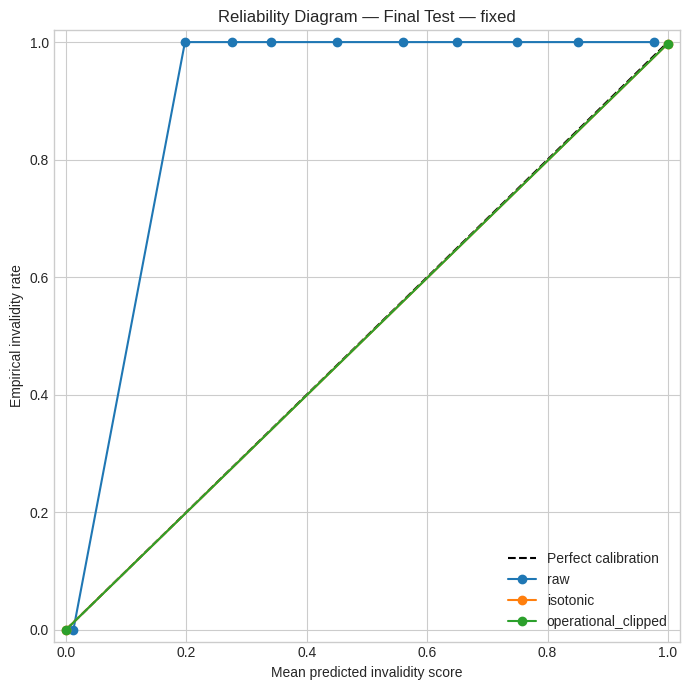

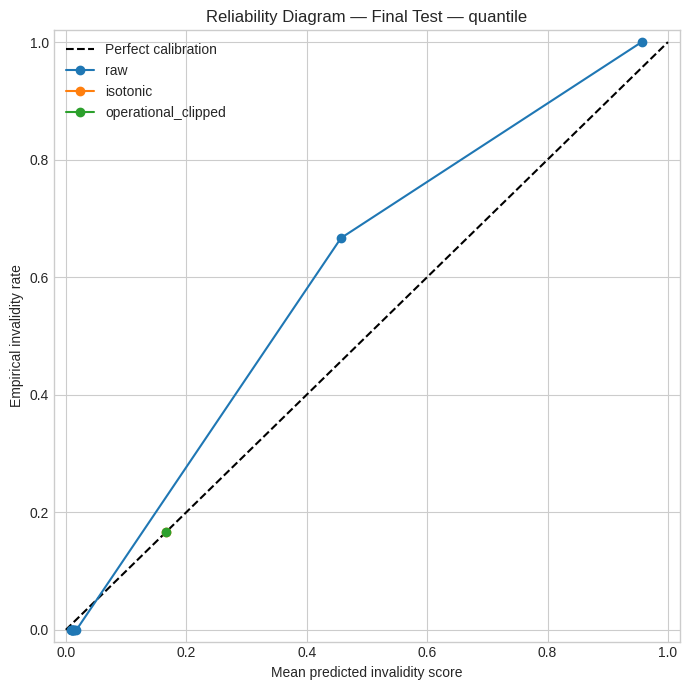

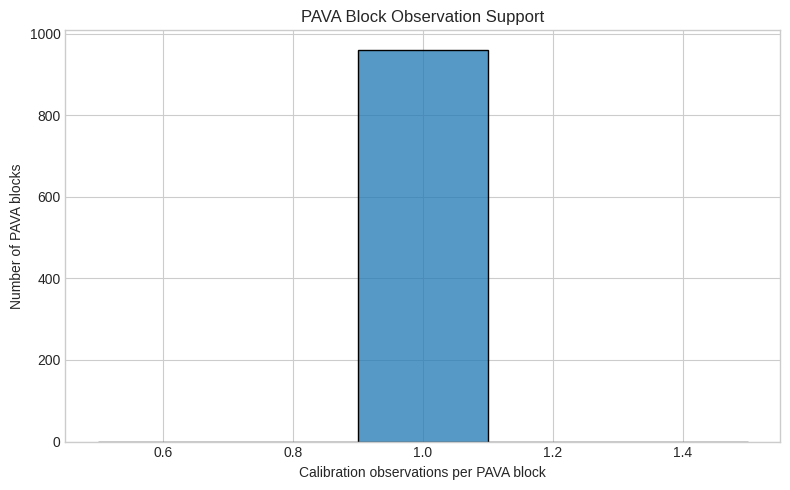

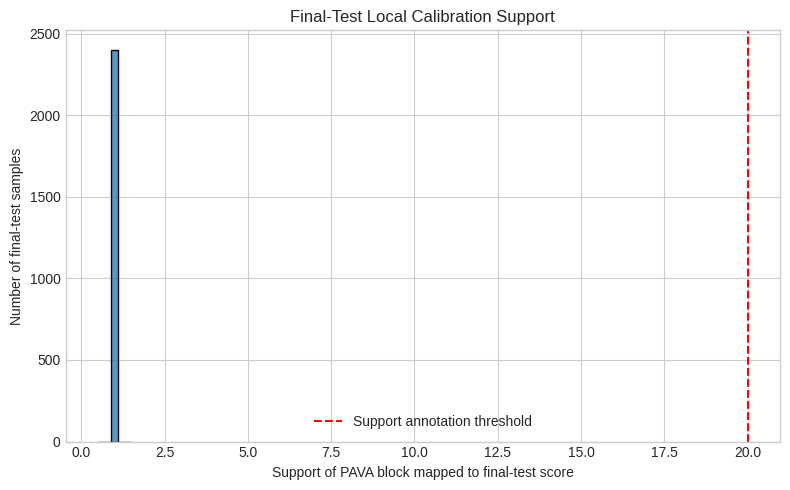

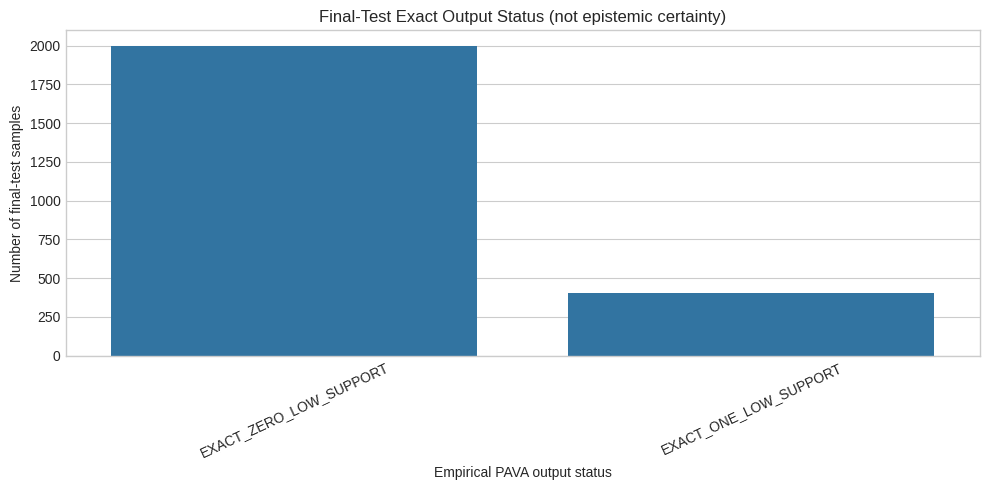

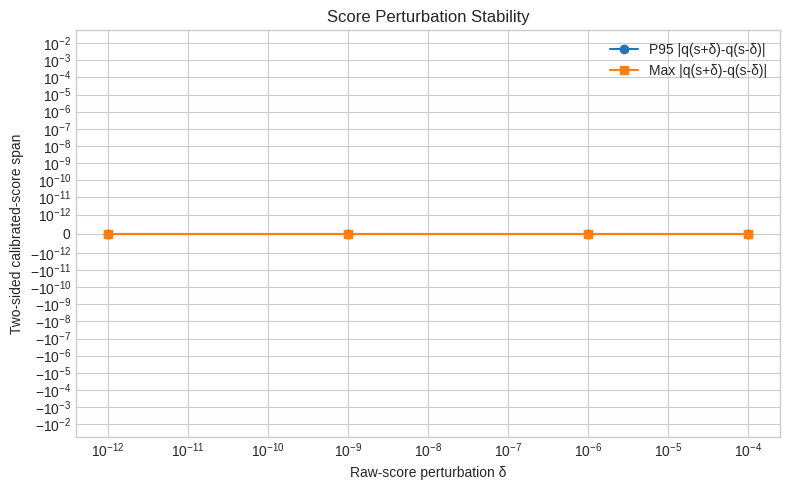

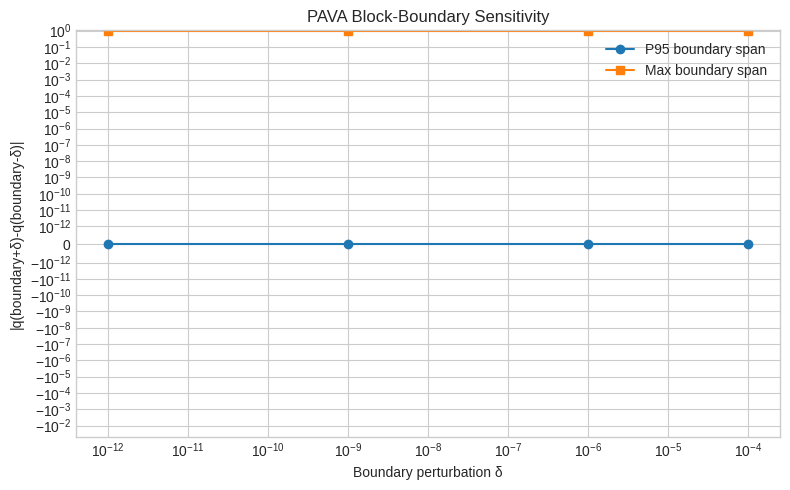


FINAL OVERALL METRICS
             method    brier  logloss  ece_fixed   auroc    auprc  brier_ci95_low  brier_ci95_high
                raw 0.009431 0.044150   0.036660 1.00000 1.000000    1.846052e-04          0.01921
           isotonic 0.000417 0.011513   0.000417 0.99975 0.997506    0.000000e+00          0.00150
operational_clipped 0.000417 0.003938   0.000483 0.99975 0.997506    1.000000e-08          0.00150

PAVA SUPPORT SUMMARY
{
  "n_calibration_samples": 960,
  "n_unique_calibration_scores": 960,
  "n_pava_blocks": 960,
  "n_singleton_blocks": 960,
  "singleton_block_fraction": 1.0,
  "singleton_mass_fraction": 1.0,
  "minimum_block_observations": 1,
  "median_block_observations": 1.0,
  "maximum_block_observations": 1,
  "n_exact_zero_blocks": 800,
  "n_exact_one_blocks": 160,
  "exact_zero_mass_fraction": 0.8333333333333334,
  "exact_one_mass_fraction": 0.16666666666666666,
  "semantic_note": "Exact 0/1 are empirical PAVA block values. They are not epistemic certainty."
}


In [ ]:
# ============================================================
# M21.2.4.3.3
# Calibration Stress, Support, and Transfer Audit
#
# Scientific contract:
# - Estimator is NOT retrained in this notebook.
# - PAVA isotonic calibration is fit ONLY on calibration split.
# - Final test is used ONLY for evaluation/audit.
# - q_invalid is a support-aware, benchmark-conditionally
#   calibrated invalidity evidence score.
# - q_invalid is NOT established as a universal probability.
# - Exact 0/1 outputs are NEVER epistemic certainty.
# - Episode bootstrap resamples whole episodes, not timesteps.
# ============================================================

from __future__ import annotations

import os
import json
import random
import hashlib
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    average_precision_score,
)


# ============================================================
# 0. CONFIG
# ============================================================

INPUT_NPZ = (
    "/content/artifacts/M21.2.4.3.1/"
    "M21_2_4_3_3_input.npz"
)

SEED = 20260912

CONFIG = {
    "experiment_name": "M21.2.4.3.3",
    "audit_version": "M21.2.4.3.3-final-step-pava-support-audit",
    "seed": SEED,

    # برای اجرای اولیه می‌توانید 300 بگذارید.
    # برای benchmark نهایی 1000 یا 2000 توصیه می‌شود.
    "n_episode_bootstrap": 1000,
    "bootstrap_ci_alpha": 0.05,

    # فقط برای جلوگیری از log(0) در محاسبه LogLoss.
    # این clipping ادعای calibration جدید ایجاد نمی‌کند.
    "metric_clip_eps": 1e-12,

    # فقط policy عملیاتی downstream است.
    "operational_clip_eps": 1e-4,

    # Threshold صرفاً annotation برای support است.
    # این مقدار certainty واقعی نیست.
    "min_certainty_block_support": 20,

    # Warning heuristic؛ نه scientific gate.
    "singleton_mass_warning_threshold": 0.50,

    "fixed_reliability_bins": 10,
    "quantile_reliability_bins": 10,

    # Stress کوچک در score خام.
    "perturbation_deltas": [
        1e-12,
        1e-9,
        1e-6,
        1e-4,
    ],

    # اگر PAVA block بسیار زیاد شد، برای boundary stress
    # حداکثر این تعداد boundary بررسی می‌شود.
    "max_boundary_stress_points": 500,

    # Support coverage فقط descriptive است.
    "support_coverage_thresholds": [
        1,
        5,
        20,
        50,
        100,
    ],

    "artifact_dir": "/content/artifacts/M21.2.4.3.3",
}

np.random.seed(SEED)
random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")

ARTIFACT_DIR = Path(CONFIG["artifact_dir"])
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

with open(ARTIFACT_DIR / "config.json", "w", encoding="utf-8") as file:
    json.dump(CONFIG, file, indent=2, ensure_ascii=False)


# ============================================================
# 1. Stable deterministic seed
# ============================================================

def stable_seed(
    *parts: Any,
    base_seed: int = 0,
    modulus: int = 2**31 - 1,
) -> int:
    """
    Stable deterministic replacement for Python hash().

    Python hash() may vary between processes/sessions.
    SHA256-based seed is reproducible across runs.
    """
    key = "::".join(map(str, parts))
    digest = hashlib.sha256(key.encode("utf-8")).digest()
    offset = int.from_bytes(
        digest[:8],
        byteorder="big",
        signed=False,
    )
    return int((int(base_seed) + offset) % modulus)


# ============================================================
# 2. NPZ input validation
# ============================================================

REQUIRED_KEYS = {
    "raw_probability_calibration",
    "y_calibration",
    "track_calibration",
    "episode_id_calibration",
    "raw_probability_test",
    "y_test",
    "track_test",
    "episode_id_test",
}


def make_episode_key(
    track: np.ndarray,
    episode_id: np.ndarray,
) -> np.ndarray:
    """
    episode_id ممکن است در فایل export شده خودش stable و globally
    unique باشد، اما این key برای robustness همواره track را هم دارد.
    """
    return np.asarray(
        [
            f"{str(track_name)}::{str(ep_id)}"
            for track_name, ep_id in zip(track, episode_id)
        ],
        dtype=str,
    )


def validate_split(
    raw_probability: np.ndarray,
    y: np.ndarray,
    track: np.ndarray,
    episode_id: np.ndarray,
    split_name: str,
) -> Dict[str, np.ndarray]:
    raw_probability = np.asarray(raw_probability, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=int).reshape(-1)
    track = np.asarray(track, dtype=str).reshape(-1)
    episode_id = np.asarray(episode_id, dtype=str).reshape(-1)

    n = len(y)

    if n == 0:
        raise ValueError(f"{split_name}: split is empty.")

    if not (
        len(raw_probability)
        == len(y)
        == len(track)
        == len(episode_id)
    ):
        raise ValueError(
            f"{split_name}: array lengths are inconsistent."
        )

    if not np.all(np.isfinite(raw_probability)):
        raise ValueError(
            f"{split_name}: raw_probability has NaN or Inf."
        )

    if np.any(raw_probability < 0.0) or np.any(raw_probability > 1.0):
        raise ValueError(
            f"{split_name}: raw_probability must lie in [0, 1]."
        )

    if not np.all(np.isin(y, [0, 1])):
        raise ValueError(
            f"{split_name}: y must contain only binary labels 0/1."
        )

    if np.any(track == ""):
        raise ValueError(f"{split_name}: empty track identity found.")

    if np.any(episode_id == ""):
        raise ValueError(f"{split_name}: empty episode identity found.")

    episode_key = make_episode_key(track, episode_id)

    return {
        "raw_probability": raw_probability,
        "y": y,
        "track": track,
        "episode_id": episode_id,
        "episode_key": episode_key,
    }


# ============================================================
# 3. Hardened weighted PAVA isotonic calibrator
#
# Important:
# - Uses tied-score grouping.
# - Uses weighted pooling.
# - Uses true PAVA merging.
# - Prediction is a monotonic STEP FUNCTION.
# - np.interp is intentionally NOT used.
# ============================================================

@dataclass
class PAVABlock:
    block_id: int
    start_group: int
    end_group: int
    x_left: float
    x_right: float
    positive_weight: float
    total_weight: float
    probability: float
    n_unique_scores: int
    n_observations: int


class IsotonicCalibrator:
    """
    Weighted Pool Adjacent Violators Algorithm.

    Fitted mapping:
        score -> monotone stepwise calibrated score

    This is PAVA step mapping, NOT linear interpolation.
    """

    def __init__(self):
        self.fitted_ = False

        self.unique_x_: Optional[np.ndarray] = None
        self.group_total_weight_: Optional[np.ndarray] = None
        self.group_positive_weight_: Optional[np.ndarray] = None
        self.group_n_obs_: Optional[np.ndarray] = None

        self.fitted_by_group_: Optional[np.ndarray] = None
        self.block_index_by_group_: Optional[np.ndarray] = None
        self.blocks_: Optional[List[PAVABlock]] = None

        self.score_min_: Optional[float] = None
        self.score_max_: Optional[float] = None
        self.block_right_edges_: Optional[np.ndarray] = None
        self.block_values_: Optional[np.ndarray] = None

    def fit(
        self,
        scores: np.ndarray,
        y: np.ndarray,
        sample_weight: Optional[np.ndarray] = None,
    ) -> "IsotonicCalibrator":
        scores = np.asarray(scores, dtype=float).reshape(-1)
        y = np.asarray(y, dtype=int).reshape(-1)

        if len(scores) == 0:
            raise ValueError("Calibration data is empty.")

        if len(scores) != len(y):
            raise ValueError("scores/y length mismatch.")

        if not np.all(np.isfinite(scores)):
            raise ValueError("Calibration scores contain NaN/Inf.")

        if not np.all(np.isin(y, [0, 1])):
            raise ValueError("Calibration labels must be binary.")

        if sample_weight is None:
            sample_weight = np.ones(len(scores), dtype=float)
        else:
            sample_weight = np.asarray(
                sample_weight,
                dtype=float,
            ).reshape(-1)

            if len(sample_weight) != len(scores):
                raise ValueError("sample_weight length mismatch.")

            if not np.all(np.isfinite(sample_weight)):
                raise ValueError("sample_weight has NaN/Inf.")

            if np.any(sample_weight <= 0.0):
                raise ValueError(
                    "sample_weight must be strictly positive."
                )

        # Stable sort for deterministic tied-score behavior.
        order = np.argsort(scores, kind="mergesort")

        sorted_scores = scores[order]
        sorted_y = y[order]
        sorted_weight = sample_weight[order]

        # Group exactly tied raw scores.
        unique_x, inverse = np.unique(
            sorted_scores,
            return_inverse=True,
        )

        n_groups = len(unique_x)

        group_total_weight = np.zeros(n_groups, dtype=float)
        group_positive_weight = np.zeros(n_groups, dtype=float)
        group_n_obs = np.zeros(n_groups, dtype=int)

        np.add.at(group_total_weight, inverse, sorted_weight)
        np.add.at(
            group_positive_weight,
            inverse,
            sorted_weight * sorted_y,
        )
        np.add.at(group_n_obs, inverse, 1)

        # PAVA stack.
        stack: List[Dict[str, Any]] = []

        for group_index in range(n_groups):
            block = {
                "start_group": int(group_index),
                "end_group": int(group_index),
                "positive_weight": float(
                    group_positive_weight[group_index]
                ),
                "total_weight": float(
                    group_total_weight[group_index]
                ),
                "n_unique_scores": 1,
                "n_observations": int(group_n_obs[group_index]),
            }

            stack.append(block)

            # Merge only monotonicity-violating adjacent blocks.
            while len(stack) >= 2:
                left = stack[-2]
                right = stack[-1]

                left_mean = (
                    left["positive_weight"]
                    / left["total_weight"]
                )

                right_mean = (
                    right["positive_weight"]
                    / right["total_weight"]
                )

                if left_mean <= right_mean:
                    break

                merged = {
                    "start_group": left["start_group"],
                    "end_group": right["end_group"],
                    "positive_weight": (
                        left["positive_weight"]
                        + right["positive_weight"]
                    ),
                    "total_weight": (
                        left["total_weight"]
                        + right["total_weight"]
                    ),
                    "n_unique_scores": (
                        left["n_unique_scores"]
                        + right["n_unique_scores"]
                    ),
                    "n_observations": (
                        left["n_observations"]
                        + right["n_observations"]
                    ),
                }

                stack[-2:] = [merged]

        fitted_by_group = np.zeros(n_groups, dtype=float)
        block_index_by_group = np.zeros(n_groups, dtype=int)

        blocks: List[PAVABlock] = []

        for block_id, block in enumerate(stack):
            probability = (
                block["positive_weight"]
                / block["total_weight"]
            )

            start_group = block["start_group"]
            end_group = block["end_group"]

            fitted_by_group[
                start_group:end_group + 1
            ] = probability

            block_index_by_group[
                start_group:end_group + 1
            ] = block_id

            blocks.append(
                PAVABlock(
                    block_id=int(block_id),
                    start_group=int(start_group),
                    end_group=int(end_group),
                    x_left=float(unique_x[start_group]),
                    x_right=float(unique_x[end_group]),
                    positive_weight=float(
                        block["positive_weight"]
                    ),
                    total_weight=float(
                        block["total_weight"]
                    ),
                    probability=float(probability),
                    n_unique_scores=int(
                        block["n_unique_scores"]
                    ),
                    n_observations=int(
                        block["n_observations"]
                    ),
                )
            )

        self.unique_x_ = unique_x
        self.group_total_weight_ = group_total_weight
        self.group_positive_weight_ = group_positive_weight
        self.group_n_obs_ = group_n_obs

        self.fitted_by_group_ = fitted_by_group
        self.block_index_by_group_ = block_index_by_group
        self.blocks_ = blocks

        self.score_min_ = float(unique_x[0])
        self.score_max_ = float(unique_x[-1])

        self.block_right_edges_ = np.asarray(
            [block.x_right for block in blocks],
            dtype=float,
        )

        self.block_values_ = np.asarray(
            [block.probability for block in blocks],
            dtype=float,
        )

        self.fitted_ = True

        self._validate_fitted_state()
        return self

    def _validate_fitted_state(self) -> None:
        if not self.fitted_:
            raise RuntimeError("Calibrator has not been fitted.")

        assert self.blocks_ is not None
        assert self.unique_x_ is not None
        assert self.block_right_edges_ is not None
        assert self.block_values_ is not None

        if len(self.blocks_) == 0:
            raise RuntimeError("No fitted PAVA blocks.")

        if not np.all(np.diff(self.block_right_edges_) >= 0.0):
            raise RuntimeError("PAVA block right edges are not monotone.")

        if not np.all(np.diff(self.block_values_) >= -1e-12):
            raise RuntimeError("PAVA fitted values are not monotone.")

        if np.any(self.block_values_ < 0.0) or np.any(
            self.block_values_ > 1.0
        ):
            raise RuntimeError("PAVA probability outside [0, 1].")

    def _check_fitted(self) -> None:
        if not self.fitted_:
            raise RuntimeError("Calibrator is not fitted.")

    def block_index(self, scores: np.ndarray) -> np.ndarray:
        """
        Step-function block lookup.

        For score s:
          - s <= first block right edge -> first block
          - otherwise -> first right edge >= s
          - above calibration range -> final block

        No interpolation is performed.
        """
        self._check_fitted()

        assert self.block_right_edges_ is not None

        scores = np.asarray(scores, dtype=float)

        if not np.all(np.isfinite(scores)):
            raise ValueError("Prediction score has NaN/Inf.")

        indices = np.searchsorted(
            self.block_right_edges_,
            scores,
            side="left",
        )

        return np.clip(
            indices,
            0,
            len(self.block_right_edges_) - 1,
        )

    def predict(self, scores: np.ndarray) -> np.ndarray:
        """
        Monotonic PAVA step mapping.
        """
        self._check_fitted()

        assert self.block_values_ is not None

        indices = self.block_index(scores)
        return self.block_values_[indices]

    def blocks_dataframe(self) -> pd.DataFrame:
        self._check_fitted()

        assert self.blocks_ is not None

        return pd.DataFrame(
            [asdict(block) for block in self.blocks_]
        )

    def predict_with_metadata(
        self,
        scores: np.ndarray,
        min_certainty_block_support: int,
        atol: float = 1e-15,
    ) -> pd.DataFrame:
        """
        Return calibrated score and its support metadata.

        Important:
        - local_support is support of the actual mapped PAVA block.
        - exact 0/1 is an empirical fitted-block value.
        - support labels never imply epistemic certainty.
        """
        self._check_fitted()

        assert self.blocks_ is not None
        assert self.score_min_ is not None
        assert self.score_max_ is not None

        scores = np.asarray(scores, dtype=float).reshape(-1)
        p = self.predict(scores)
        indices = self.block_index(scores)

        rows = []

        for score, calibrated_score, block_id in zip(
            scores,
            p,
            indices,
        ):
            block = self.blocks_[int(block_id)]

            if score < self.score_min_:
                extrapolation_status = (
                    "BELOW_CALIBRATION_SCORE_RANGE"
                )
            elif score > self.score_max_:
                extrapolation_status = (
                    "ABOVE_CALIBRATION_SCORE_RANGE"
                )
            else:
                extrapolation_status = "IN_CALIBRATION_SCORE_RANGE"

            if np.isclose(calibrated_score, 0.0, atol=atol):
                if (
                    block.n_observations
                    >= min_certainty_block_support
                ):
                    exact_output_status = (
                        "EXACT_ZERO_WITH_SUPPORT"
                    )
                else:
                    exact_output_status = (
                        "EXACT_ZERO_LOW_SUPPORT"
                    )

            elif np.isclose(calibrated_score, 1.0, atol=atol):
                if (
                    block.n_observations
                    >= min_certainty_block_support
                ):
                    exact_output_status = (
                        "EXACT_ONE_WITH_SUPPORT"
                    )
                else:
                    exact_output_status = (
                        "EXACT_ONE_LOW_SUPPORT"
                    )

            else:
                exact_output_status = "NON_EXTREME"

            rows.append(
                {
                    "raw_probability": float(score),
                    "q_invalid_isotonic": float(calibrated_score),

                    "mapped_block_id": int(block.block_id),
                    "mapped_block_left_score": float(
                        block.x_left
                    ),
                    "mapped_block_right_score": float(
                        block.x_right
                    ),

                    "local_support": float(block.total_weight),
                    "local_n_observations": int(
                        block.n_observations
                    ),
                    "local_positive_mass": float(
                        block.positive_weight
                    ),
                    "local_empirical_rate": float(
                        block.probability
                    ),

                    "mapping_mode": "PAVA_STEP_MAPPING",
                    "extrapolation_status": extrapolation_status,
                    "exact_output_status": exact_output_status,
                }
            )

        return pd.DataFrame(rows)

    def support_summary(self) -> Dict[str, Any]:
        blocks = self.blocks_dataframe()

        total_mass = float(blocks["total_weight"].sum())

        singleton = blocks[
            blocks["n_observations"] == 1
        ]

        exact_zero = blocks[
            np.isclose(blocks["probability"], 0.0)
        ]

        exact_one = blocks[
            np.isclose(blocks["probability"], 1.0)
        ]

        return {
            "n_calibration_samples": int(
                blocks["n_observations"].sum()
            ),
            "n_unique_calibration_scores": int(
                len(self.unique_x_)
            ),
            "n_pava_blocks": int(len(blocks)),

            "n_singleton_blocks": int(len(singleton)),
            "singleton_block_fraction": float(
                len(singleton) / max(1, len(blocks))
            ),
            "singleton_mass_fraction": float(
                singleton["total_weight"].sum()
                / max(total_mass, 1e-12)
            ),

            "minimum_block_observations": int(
                blocks["n_observations"].min()
            ),
            "median_block_observations": float(
                blocks["n_observations"].median()
            ),
            "maximum_block_observations": int(
                blocks["n_observations"].max()
            ),

            "n_exact_zero_blocks": int(len(exact_zero)),
            "n_exact_one_blocks": int(len(exact_one)),

            "exact_zero_mass_fraction": float(
                exact_zero["total_weight"].sum()
                / max(total_mass, 1e-12)
            ),
            "exact_one_mass_fraction": float(
                exact_one["total_weight"].sum()
                / max(total_mass, 1e-12)
            ),

            "semantic_note": (
                "Exact 0/1 are empirical PAVA block values. "
                "They are not epistemic certainty."
            ),
        }


# ============================================================
# 4. PAVA unit tests
# ============================================================

def run_pava_unit_tests() -> Dict[str, str]:
    results: Dict[str, str] = {}

    calibrator = IsotonicCalibrator().fit(
        scores=np.array([0.1, 0.2, 0.3, 0.4]),
        y=np.array([0, 1, 0, 1]),
    )

    outputs = calibrator.predict(
        np.array([0.1, 0.2, 0.3, 0.4])
    )

    assert np.all(np.diff(outputs) >= -1e-12)
    results["monotonicity"] = "PASS"

    tied = IsotonicCalibrator().fit(
        scores=np.array([0.2, 0.2, 0.2, 0.8]),
        y=np.array([0, 1, 1, 1]),
    )

    tied_output = tied.predict(np.array([0.2]))[0]

    assert abs(tied_output - (2.0 / 3.0)) < 1e-12
    results["tied_score_grouping"] = "PASS"

    weighted = IsotonicCalibrator().fit(
        scores=np.array([0.1, 0.2]),
        y=np.array([1, 0]),
        sample_weight=np.array([3.0, 1.0]),
    )

    weighted_output = weighted.predict(
        np.array([0.1, 0.2])
    )

    assert np.allclose(weighted_output, [0.75, 0.75])
    results["weighted_pooling"] = "PASS"

    # Confirm actual step mapping; no linear interpolation.
    step_test = IsotonicCalibrator().fit(
        scores=np.array([0.1, 0.2]),
        y=np.array([0, 1]),
    )

    interior_value = step_test.predict(np.array([0.15]))[0]

    assert interior_value == 1.0
    results["step_mapping_not_interpolation"] = "PASS"

    try:
        IsotonicCalibrator().fit(
            scores=np.array([0.1, np.nan]),
            y=np.array([0, 1]),
        )
        raise AssertionError("Expected non-finite rejection.")
    except ValueError:
        results["nonfinite_rejection"] = "PASS"

    try:
        IsotonicCalibrator().fit(
            scores=np.array([0.1, 0.2]),
            y=np.array([0, 2]),
        )
        raise AssertionError("Expected non-binary rejection.")
    except ValueError:
        results["nonbinary_label_rejection"] = "PASS"

    return results


# ============================================================
# 5. Metrics
# ============================================================

PREDICTION_COLUMNS = {
    "raw": "raw_probability",
    "isotonic": "q_invalid_isotonic",
    "operational_clipped": "q_invalid_operational",
}


def safe_metrics(
    y: np.ndarray,
    p: np.ndarray,
) -> Dict[str, Optional[float]]:
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)

    result: Dict[str, Optional[float]] = {
        "n_samples": int(len(y)),
        "prevalence_invalid": float(np.mean(y)),
        "brier": float(brier_score_loss(y, p)),
        "logloss": float(
            log_loss(
                y,
                np.clip(
                    p,
                    CONFIG["metric_clip_eps"],
                    1.0 - CONFIG["metric_clip_eps"],
                ),
                labels=[0, 1],
            )
        ),
        "auroc": None,
        "auprc": None,
    }

    if len(np.unique(y)) == 2:
        result["auroc"] = float(roc_auc_score(y, p))
        result["auprc"] = float(
            average_precision_score(y, p)
        )

    return result


def fixed_edges() -> np.ndarray:
    return np.linspace(
        0.0,
        1.0,
        CONFIG["fixed_reliability_bins"] + 1,
    )


def quantile_edges(p: np.ndarray) -> np.ndarray:
    p = np.asarray(p, dtype=float)

    edges = np.unique(
        np.quantile(
            p,
            np.linspace(
                0.0,
                1.0,
                CONFIG["quantile_reliability_bins"] + 1,
            ),
        )
    )

    if len(edges) < 2:
        return np.array([0.0, 1.0])

    edges[0] = 0.0
    edges[-1] = 1.0

    return edges


def expected_calibration_error(
    y: np.ndarray,
    p: np.ndarray,
    edges: np.ndarray,
) -> float:
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)

    bins = np.digitize(
        p,
        edges[1:-1],
        right=False,
    )

    total = 0.0

    for bin_index in range(len(edges) - 1):
        mask = bins == bin_index

        if int(mask.sum()) == 0:
            continue

        total += (
            float(mask.mean())
            * abs(float(y[mask].mean()) - float(p[mask].mean()))
        )

    return float(total)


def reliability_table(
    y: np.ndarray,
    p: np.ndarray,
    edges: np.ndarray,
    method: str,
    binning: str,
) -> pd.DataFrame:
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)

    bins = np.digitize(
        p,
        edges[1:-1],
        right=False,
    )

    rows = []

    for bin_index in range(len(edges) - 1):
        mask = bins == bin_index

        if int(mask.sum()) == 0:
            rows.append(
                {
                    "method": method,
                    "binning": binning,
                    "bin_index": int(bin_index),
                    "bin_left": float(edges[bin_index]),
                    "bin_right": float(edges[bin_index + 1]),
                    "n_samples": 0,
                    "mean_prediction": np.nan,
                    "empirical_invalidity": np.nan,
                    "absolute_gap": np.nan,
                }
            )
            continue

        mean_prediction = float(p[mask].mean())
        empirical_invalidity = float(y[mask].mean())

        rows.append(
            {
                "method": method,
                "binning": binning,
                "bin_index": int(bin_index),
                "bin_left": float(edges[bin_index]),
                "bin_right": float(edges[bin_index + 1]),
                "n_samples": int(mask.sum()),
                "mean_prediction": mean_prediction,
                "empirical_invalidity": empirical_invalidity,
                "absolute_gap": abs(
                    empirical_invalidity - mean_prediction
                ),
            }
        )

    return pd.DataFrame(rows)


# ============================================================
# 6. Episode bootstrap
# ============================================================

def make_episode_index_map(
    episode_keys: np.ndarray,
) -> Dict[str, np.ndarray]:
    episode_keys = np.asarray(episode_keys, dtype=str)
    unique_episodes = np.unique(episode_keys)

    return {
        episode: np.flatnonzero(episode_keys == episode)
        for episode in unique_episodes
    }


def episode_bootstrap_ci(
    y: np.ndarray,
    p: np.ndarray,
    episode_keys: np.ndarray,
    metric_name: str,
    seed: int,
) -> Tuple[float, float]:
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    episode_keys = np.asarray(episode_keys, dtype=str)

    episode_map = make_episode_index_map(episode_keys)
    unique_episodes = np.asarray(
        sorted(episode_map.keys()),
        dtype=str,
    )

    rng = np.random.default_rng(seed)
    values = []

    for _ in range(CONFIG["n_episode_bootstrap"]):
        sampled_episodes = rng.choice(
            unique_episodes,
            size=len(unique_episodes),
            replace=True,
        )

        sampled_indices = np.concatenate(
            [
                episode_map[episode]
                for episode in sampled_episodes
            ]
        )

        y_boot = y[sampled_indices]
        p_boot = p[sampled_indices]

        if metric_name == "brier":
            value = brier_score_loss(y_boot, p_boot)

        elif metric_name == "logloss":
            value = log_loss(
                y_boot,
                np.clip(
                    p_boot,
                    CONFIG["metric_clip_eps"],
                    1.0 - CONFIG["metric_clip_eps"],
                ),
                labels=[0, 1],
            )

        elif metric_name == "ece_fixed":
            value = expected_calibration_error(
                y_boot,
                p_boot,
                fixed_edges(),
            )

        else:
            raise ValueError(
                f"Unknown bootstrap metric: {metric_name}"
            )

        values.append(float(value))

    alpha = CONFIG["bootstrap_ci_alpha"]

    return (
        float(np.quantile(values, alpha / 2.0)),
        float(np.quantile(values, 1.0 - alpha / 2.0)),
    )


# ============================================================
# 7. Prediction tables
# ============================================================

def build_prediction_table(
    split: Dict[str, np.ndarray],
    split_name: str,
    calibrator: IsotonicCalibrator,
    calibration_domain_tracks: set,
) -> pd.DataFrame:
    metadata = calibrator.predict_with_metadata(
        split["raw_probability"],
        min_certainty_block_support=CONFIG[
            "min_certainty_block_support"
        ],
    )

    df = pd.DataFrame(
        {
            "split": split_name,
            "y_invalid": split["y"],
            "track": split["track"],
            "episode_id": split["episode_id"],
            "episode_key": split["episode_key"],
        }
    )

    df = pd.concat(
        [
            df.reset_index(drop=True),
            metadata.reset_index(drop=True),
        ],
        axis=1,
    )

    df["q_invalid_operational"] = np.clip(
        df["q_invalid_isotonic"].to_numpy(),
        CONFIG["operational_clip_eps"],
        1.0 - CONFIG["operational_clip_eps"],
    )

    df["calibration_domain"] = np.where(
        df["track"].isin(calibration_domain_tracks),
        "IN_DOMAIN_TRACK_FAMILY",
        "UNSEEN_TRACK_FAMILY",
    )

    return df


# ============================================================
# 8. Overall, track-wise, transfer metrics
# ============================================================

def overall_metrics(test_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    y = test_df["y_invalid"].to_numpy()
    episode_keys = test_df["episode_key"].to_numpy()

    for method, prediction_column in PREDICTION_COLUMNS.items():
        p = test_df[prediction_column].to_numpy()

        metrics = safe_metrics(y, p)

        metrics["ece_fixed"] = expected_calibration_error(
            y,
            p,
            fixed_edges(),
        )

        metrics["ece_quantile"] = expected_calibration_error(
            y,
            p,
            quantile_edges(p),
        )

        for metric_name in [
            "brier",
            "logloss",
            "ece_fixed",
        ]:
            ci_low, ci_high = episode_bootstrap_ci(
                y=y,
                p=p,
                episode_keys=episode_keys,
                metric_name=metric_name,
                seed=stable_seed(
                    "overall-bootstrap",
                    method,
                    metric_name,
                    base_seed=CONFIG["seed"],
                ),
            )

            metrics[f"{metric_name}_ci95_low"] = ci_low
            metrics[f"{metric_name}_ci95_high"] = ci_high

        rows.append(
            {
                "split": "final_test",
                "method": method,
                **metrics,
            }
        )

    return pd.DataFrame(rows)


def trackwise_metrics(test_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for track_name, track_df in test_df.groupby(
        "track",
        sort=True,
    ):
        y = track_df["y_invalid"].to_numpy()
        episode_keys = track_df["episode_key"].to_numpy()

        for method, prediction_column in PREDICTION_COLUMNS.items():
            p = track_df[prediction_column].to_numpy()

            metrics = safe_metrics(y, p)

            metrics["ece_fixed"] = expected_calibration_error(
                y,
                p,
                fixed_edges(),
            )

            row = {
                "track": str(track_name),
                "calibration_domain": str(
                    track_df["calibration_domain"].iloc[0]
                ),
                "method": method,
                "n_episodes": int(
                    track_df["episode_key"].nunique()
                ),
                "mean_prediction": float(p.mean()),
                "p95_prediction": float(np.quantile(p, 0.95)),
                "p99_prediction": float(np.quantile(p, 0.99)),
                **metrics,
            }

            for metric_name in [
                "brier",
                "logloss",
                "ece_fixed",
            ]:
                ci_low, ci_high = episode_bootstrap_ci(
                    y=y,
                    p=p,
                    episode_keys=episode_keys,
                    metric_name=metric_name,
                    seed=stable_seed(
                        "trackwise-bootstrap",
                        track_name,
                        method,
                        metric_name,
                        base_seed=CONFIG["seed"],
                    ),
                )

                row[f"{metric_name}_ci95_low"] = ci_low
                row[f"{metric_name}_ci95_high"] = ci_high

            rows.append(row)

    return pd.DataFrame(rows)


def transfer_metrics(test_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for domain_name, domain_df in test_df.groupby(
        "calibration_domain",
        sort=True,
    ):
        y = domain_df["y_invalid"].to_numpy()

        row: Dict[str, Any] = {
            "domain": str(domain_name),
            "tracks": ", ".join(
                sorted(domain_df["track"].unique().tolist())
            ),
            "n_samples": int(len(domain_df)),
            "n_episodes": int(
                domain_df["episode_key"].nunique()
            ),
            "prevalence_invalid": float(y.mean()),
            "scientific_scope": (
                "IN_DOMAIN descriptive calibration audit"
                if domain_name == "IN_DOMAIN_TRACK_FAMILY"
                else (
                    "OUT_OF_TRACK-FAMILY performance audit; "
                    "does not establish universal calibration transfer"
                )
            ),
        }

        for method, prediction_column in PREDICTION_COLUMNS.items():
            p = domain_df[prediction_column].to_numpy()
            metrics = safe_metrics(y, p)

            row[f"{method}_brier"] = metrics["brier"]
            row[f"{method}_logloss"] = metrics["logloss"]
            row[f"{method}_auroc"] = metrics["auroc"]
            row[f"{method}_auprc"] = metrics["auprc"]
            row[f"{method}_ece_fixed"] = (
                expected_calibration_error(
                    y,
                    p,
                    fixed_edges(),
                )
            )

        rows.append(row)

    return pd.DataFrame(rows)


# ============================================================
# 9. Exact output audit
# ============================================================

def exact_output_audit(
    test_df: pd.DataFrame,
) -> Tuple[Dict[str, Any], pd.DataFrame]:
    y = test_df["y_invalid"].to_numpy()
    p = test_df["q_invalid_isotonic"].to_numpy()

    exact_zero = np.isclose(p, 0.0)
    exact_one = np.isclose(p, 1.0)

    valid_mapped_to_one = (y == 0) & exact_one
    invalid_mapped_to_zero = (y == 1) & exact_zero

    low_support_extreme = test_df[
        "exact_output_status"
    ].isin(
        [
            "EXACT_ZERO_LOW_SUPPORT",
            "EXACT_ONE_LOW_SUPPORT",
        ]
    ).to_numpy()

    forensic_mask = (
        valid_mapped_to_one
        | invalid_mapped_to_zero
        | low_support_extreme
    )

    summary = {
        "n_samples": int(len(test_df)),
        "n_exact_zero_predictions": int(exact_zero.sum()),
        "n_exact_one_predictions": int(exact_one.sum()),

        "valid_samples_mapped_to_exact_one": int(
            valid_mapped_to_one.sum()
        ),
        "invalid_samples_mapped_to_exact_zero": int(
            invalid_mapped_to_zero.sum()
        ),

        "low_support_extreme_count": int(
            low_support_extreme.sum()
        ),

        "false_extreme_counterexample_exists": bool(
            valid_mapped_to_one.sum() > 0
            or invalid_mapped_to_zero.sum() > 0
        ),

        "semantic_conclusion": (
            "Exact 0/1 output is not authorized as epistemic "
            "certainty, even when the corresponding empirical "
            "PAVA block has high observed support."
        ),
    }

    forensic_columns = [
        "split",
        "track",
        "episode_id",
        "episode_key",
        "y_invalid",

        "raw_probability",
        "q_invalid_isotonic",
        "q_invalid_operational",

        "mapped_block_id",
        "mapped_block_left_score",
        "mapped_block_right_score",

        "local_support",
        "local_n_observations",
        "local_positive_mass",
        "local_empirical_rate",

        "mapping_mode",
        "extrapolation_status",
        "exact_output_status",
        "calibration_domain",
    ]

    forensic = test_df.loc[
        forensic_mask,
        forensic_columns,
    ].copy()

    return summary, forensic


# ============================================================
# 10. Score perturbation stability audit
# ============================================================

def perturbation_audit(
    calibrator: IsotonicCalibrator,
    test_df: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    scores = test_df["raw_probability"].to_numpy()
    p_base = calibrator.predict(scores)

    rows = []

    for delta in CONFIG["perturbation_deltas"]:
        score_minus = np.clip(scores - delta, 0.0, 1.0)
        score_plus = np.clip(scores + delta, 0.0, 1.0)

        p_minus = calibrator.predict(score_minus)
        p_plus = calibrator.predict(score_plus)

        span = np.abs(p_plus - p_minus)

        for i in range(len(scores)):
            rows.append(
                {
                    "row_index": int(i),
                    "track": str(test_df["track"].iloc[i]),
                    "episode_key": str(
                        test_df["episode_key"].iloc[i]
                    ),
                    "delta": float(delta),

                    "score": float(scores[i]),
                    "p_base": float(p_base[i]),
                    "p_minus": float(p_minus[i]),
                    "p_plus": float(p_plus[i]),

                    "two_sided_span_change": float(span[i]),
                    "exact_output_status": str(
                        test_df["exact_output_status"].iloc[i]
                    ),
                    "local_support": float(
                        test_df["local_support"].iloc[i]
                    ),
                }
            )

    detailed = pd.DataFrame(rows)

    summary_rows = []

    for delta, delta_df in detailed.groupby(
        "delta",
        sort=True,
    ):
        values = delta_df[
            "two_sided_span_change"
        ].to_numpy()

        summary_rows.append(
            {
                "delta": float(delta),
                "n_scores": int(len(delta_df)),

                "mean_span_change": float(values.mean()),
                "median_span_change": float(
                    np.median(values)
                ),
                "p95_span_change": float(
                    np.quantile(values, 0.95)
                ),
                "p99_span_change": float(
                    np.quantile(values, 0.99)
                ),
                "max_span_change": float(values.max()),

                "fraction_span_gt_1e_4": float(
                    (values > 1e-4).mean()
                ),
                "fraction_span_gt_1e_2": float(
                    (values > 1e-2).mean()
                ),
            }
        )

    return detailed, pd.DataFrame(summary_rows)


# ============================================================
# 11. PAVA block-boundary sensitivity audit
#
# Boundary is the right edge of each block except final block.
# PAVA step mapping may jump immediately after such boundary.
# ============================================================

def boundary_audit(
    calibrator: IsotonicCalibrator,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    blocks = calibrator.blocks_dataframe().sort_values(
        "block_id"
    ).reset_index(drop=True)

    detailed_columns = [
        "boundary_index",
        "left_block_id",
        "right_block_id",
        "boundary_score",
        "delta",
        "left_score",
        "right_score",
        "p_left",
        "p_right",
        "two_sided_boundary_span",
    ]

    summary_columns = [
        "delta",
        "n_boundaries",
        "mean_boundary_span",
        "median_boundary_span",
        "p95_boundary_span",
        "p99_boundary_span",
        "max_boundary_span",
        "fraction_span_gt_1e_4",
        "fraction_span_gt_1e_2",
    ]

    if len(blocks) < 2:
        return (
            pd.DataFrame(columns=detailed_columns),
            pd.DataFrame(columns=summary_columns),
        )

    boundary_records = []

    for i in range(len(blocks) - 1):
        left_block = blocks.iloc[i]
        right_block = blocks.iloc[i + 1]

        boundary_records.append(
            {
                "left_block_id": int(left_block["block_id"]),
                "right_block_id": int(right_block["block_id"]),
                "boundary_score": float(left_block["x_right"]),
            }
        )

    max_n = CONFIG["max_boundary_stress_points"]

    if (
        max_n is not None
        and len(boundary_records) > int(max_n)
    ):
        rng = np.random.default_rng(
            stable_seed(
                "boundary-subsample",
                len(boundary_records),
                base_seed=CONFIG["seed"],
            )
        )

        selected = rng.choice(
            len(boundary_records),
            size=int(max_n),
            replace=False,
        )

        boundary_records = [
            boundary_records[i]
            for i in sorted(selected.tolist())
        ]

    rows = []

    for boundary_index, record in enumerate(boundary_records):
        boundary_score = float(record["boundary_score"])

        for delta in CONFIG["perturbation_deltas"]:
            # left side: slightly below the PAVA boundary
            left_score = max(0.0, boundary_score - delta)

            # right side: slightly above the PAVA boundary
            right_score = min(1.0, boundary_score + delta)

            p_left = float(
                calibrator.predict(np.array([left_score]))[0]
            )

            p_right = float(
                calibrator.predict(np.array([right_score]))[0]
            )

            rows.append(
                {
                    "boundary_index": int(boundary_index),
                    "left_block_id": int(
                        record["left_block_id"]
                    ),
                    "right_block_id": int(
                        record["right_block_id"]
                    ),

                    "boundary_score": boundary_score,
                    "delta": float(delta),

                    "left_score": float(left_score),
                    "right_score": float(right_score),

                    "p_left": p_left,
                    "p_right": p_right,

                    "two_sided_boundary_span": abs(
                        p_right - p_left
                    ),
                }
            )

    detailed = pd.DataFrame(
        rows,
        columns=detailed_columns,
    )

    summary_rows = []

    for delta, delta_df in detailed.groupby(
        "delta",
        sort=True,
    ):
        values = delta_df[
            "two_sided_boundary_span"
        ].to_numpy()

        summary_rows.append(
            {
                "delta": float(delta),
                "n_boundaries": int(len(delta_df)),

                "mean_boundary_span": float(values.mean()),
                "median_boundary_span": float(
                    np.median(values)
                ),
                "p95_boundary_span": float(
                    np.quantile(values, 0.95)
                ),
                "p99_boundary_span": float(
                    np.quantile(values, 0.99)
                ),
                "max_boundary_span": float(values.max()),

                "fraction_span_gt_1e_4": float(
                    (values > 1e-4).mean()
                ),
                "fraction_span_gt_1e_2": float(
                    (values > 1e-2).mean()
                ),
            }
        )

    summary = pd.DataFrame(
        summary_rows,
        columns=summary_columns,
    )

    return detailed, summary


# ============================================================
# 12. Support coverage audit
# ============================================================

def support_coverage_audit(
    test_df: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    total_episodes = max(
        1,
        int(test_df["episode_key"].nunique()),
    )

    for threshold in CONFIG["support_coverage_thresholds"]:
        mask = test_df["local_support"] >= float(threshold)

        n_episodes = int(
            test_df.loc[mask, "episode_key"].nunique()
        )

        rows.append(
            {
                "support_condition": f"LOCAL_SUPPORT_GE_{threshold}",
                "n_samples": int(mask.sum()),
                "fraction_test_mass": float(mask.mean()),
                "n_episodes": n_episodes,
                "fraction_test_episodes": float(
                    n_episodes / total_episodes
                ),
            }
        )

    special_masks = {
        "EXTRAPOLATED_SCORE_RANGE": (
            test_df["extrapolation_status"]
            != "IN_CALIBRATION_SCORE_RANGE"
        ),
        "EXACT_ZERO_LOW_SUPPORT": (
            test_df["exact_output_status"]
            == "EXACT_ZERO_LOW_SUPPORT"
        ),
        "EXACT_ONE_LOW_SUPPORT": (
            test_df["exact_output_status"]
            == "EXACT_ONE_LOW_SUPPORT"
        ),
        "ANY_LOW_SUPPORT_EXTREME": test_df[
            "exact_output_status"
        ].isin(
            [
                "EXACT_ZERO_LOW_SUPPORT",
                "EXACT_ONE_LOW_SUPPORT",
            ]
        ),
    }

    for condition_name, mask in special_masks.items():
        n_episodes = int(
            test_df.loc[mask, "episode_key"].nunique()
        )

        rows.append(
            {
                "support_condition": condition_name,
                "n_samples": int(mask.sum()),
                "fraction_test_mass": float(mask.mean()),
                "n_episodes": n_episodes,
                "fraction_test_episodes": float(
                    n_episodes / total_episodes
                ),
            }
        )

    return pd.DataFrame(rows)


# ============================================================
# 13. Reliability artifacts
# ============================================================

def reliability_artifacts(
    test_df: pd.DataFrame,
) -> pd.DataFrame:
    all_tables = []

    y = test_df["y_invalid"].to_numpy()

    for method, prediction_column in PREDICTION_COLUMNS.items():
        p = test_df[prediction_column].to_numpy()

        fixed_table = reliability_table(
            y=y,
            p=p,
            edges=fixed_edges(),
            method=method,
            binning="fixed",
        )

        quantile_table = reliability_table(
            y=y,
            p=p,
            edges=quantile_edges(p),
            method=method,
            binning="quantile",
        )

        all_tables.extend([
            fixed_table,
            quantile_table,
        ])

    reliability_df = pd.concat(
        all_tables,
        ignore_index=True,
    )

    reliability_df.to_csv(
        ARTIFACT_DIR / "reliability_tables.csv",
        index=False,
    )

    for binning in ["fixed", "quantile"]:
        fig, ax = plt.subplots(figsize=(7, 7))

        ax.plot(
            [0.0, 1.0],
            [0.0, 1.0],
            linestyle="--",
            color="black",
            label="Perfect calibration",
        )

        for method in PREDICTION_COLUMNS:
            plot_df = reliability_df[
                (reliability_df["method"] == method)
                & (reliability_df["binning"] == binning)
                & (reliability_df["n_samples"] > 0)
            ]

            ax.plot(
                plot_df["mean_prediction"],
                plot_df["empirical_invalidity"],
                marker="o",
                label=method,
            )

        ax.set_title(
            f"Reliability Diagram — Final Test — {binning}"
        )
        ax.set_xlabel("Mean predicted invalidity score")
        ax.set_ylabel("Empirical invalidity rate")
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.legend()

        plt.tight_layout()

        plt.savefig(
            ARTIFACT_DIR / f"reliability_{binning}.png",
            dpi=180,
        )

        plt.show()
        plt.close()

    return reliability_df


# ============================================================
# 14. Independent diagnostic plots
# ============================================================

def diagnostic_plots(
    blocks_df: pd.DataFrame,
    test_df: pd.DataFrame,
    perturbation_summary_df: pd.DataFrame,
    boundary_summary_df: pd.DataFrame,
) -> None:
    # --------------------------------------------------------
    # Plot 1: calibration PAVA block support distribution
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.histplot(
        data=blocks_df,
        x="n_observations",
        bins=min(
            30,
            max(5, int(blocks_df["n_observations"].nunique())),
        ),
        ax=ax,
    )

    ax.set_title("PAVA Block Observation Support")
    ax.set_xlabel("Calibration observations per PAVA block")
    ax.set_ylabel("Number of PAVA blocks")

    plt.tight_layout()

    plt.savefig(
        ARTIFACT_DIR / "support_distribution.png",
        dpi=180,
    )

    plt.show()
    plt.close()

    # --------------------------------------------------------
    # Plot 2: final-test local support distribution
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.histplot(
        data=test_df,
        x="local_support",
        bins=min(
            30,
            max(5, int(test_df["local_support"].nunique())),
        ),
        ax=ax,
    )

    ax.axvline(
        CONFIG["min_certainty_block_support"],
        linestyle="--",
        color="red",
        label="Support annotation threshold",
    )

    ax.set_title(
        "Final-Test Local Calibration Support"
    )
    ax.set_xlabel(
        "Support of PAVA block mapped to final-test score"
    )
    ax.set_ylabel("Number of final-test samples")
    ax.legend()

    plt.tight_layout()

    plt.savefig(
        ARTIFACT_DIR / "local_support_distribution.png",
        dpi=180,
    )

    plt.show()
    plt.close()

    # --------------------------------------------------------
    # Plot 3: exact output status
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(10, 5))

    status_counts = (
        test_df["exact_output_status"]
        .value_counts()
        .rename_axis("exact_output_status")
        .reset_index(name="count")
    )

    sns.barplot(
        data=status_counts,
        x="exact_output_status",
        y="count",
        ax=ax,
    )

    ax.tick_params(axis="x", rotation=25)
    ax.set_title(
        "Final-Test Exact Output Status "
        "(not epistemic certainty)"
    )
    ax.set_xlabel("Empirical PAVA output status")
    ax.set_ylabel("Number of final-test samples")

    plt.tight_layout()

    plt.savefig(
        ARTIFACT_DIR / "certainty_status.png",
        dpi=180,
    )

    plt.show()
    plt.close()

    # --------------------------------------------------------
    # Plot 4: score perturbation stability
    # --------------------------------------------------------

    if len(perturbation_summary_df) > 0:
        fig, ax = plt.subplots(figsize=(8, 5))

        ax.plot(
            perturbation_summary_df["delta"],
            perturbation_summary_df["p95_span_change"],
            marker="o",
            label="P95 |q(s+δ)-q(s-δ)|",
        )

        ax.plot(
            perturbation_summary_df["delta"],
            perturbation_summary_df["max_span_change"],
            marker="s",
            label="Max |q(s+δ)-q(s-δ)|",
        )

        ax.set_xscale("log")
        ax.set_yscale("symlog", linthresh=1e-12)

        ax.set_title("Score Perturbation Stability")
        ax.set_xlabel("Raw-score perturbation δ")
        ax.set_ylabel(
            "Two-sided calibrated-score span"
        )
        ax.legend()

        plt.tight_layout()

        plt.savefig(
            ARTIFACT_DIR / "score_perturbation_stability.png",
            dpi=180,
        )

        plt.show()
        plt.close()

    # --------------------------------------------------------
    # Plot 5: block-boundary sensitivity
    # --------------------------------------------------------

    if len(boundary_summary_df) > 0:
        fig, ax = plt.subplots(figsize=(8, 5))

        ax.plot(
            boundary_summary_df["delta"],
            boundary_summary_df["p95_boundary_span"],
            marker="o",
            label="P95 boundary span",
        )

        ax.plot(
            boundary_summary_df["delta"],
            boundary_summary_df["max_boundary_span"],
            marker="s",
            label="Max boundary span",
        )

        ax.set_xscale("log")
        ax.set_yscale("symlog", linthresh=1e-12)

        ax.set_title("PAVA Block-Boundary Sensitivity")
        ax.set_xlabel("Boundary perturbation δ")
        ax.set_ylabel("|q(boundary+δ)-q(boundary-δ)|")
        ax.legend()

        plt.tight_layout()

        plt.savefig(
            ARTIFACT_DIR / "block_boundary_sensitivity.png",
            dpi=180,
        )

        plt.show()
        plt.close()


# ============================================================
# 15. Final scientific verdict
# ============================================================

def generate_verdict(
    support_summary: Dict[str, Any],
    exact_summary: Dict[str, Any],
    support_coverage_df: pd.DataFrame,
) -> Dict[str, Any]:
    singleton_mass_fraction = float(
        support_summary["singleton_mass_fraction"]
    )

    warning_triggered = (
        singleton_mass_fraction
        >= CONFIG["singleton_mass_warning_threshold"]
    )

    extrapolation_rows = support_coverage_df[
        support_coverage_df["support_condition"]
        == "EXTRAPOLATED_SCORE_RANGE"
    ]

    if len(extrapolation_rows) > 0:
        extrapolation_fraction = float(
            extrapolation_rows[
                "fraction_test_mass"
            ].iloc[0]
        )
    else:
        extrapolation_fraction = None

    return {
        "engineering_pipeline_status": "PASS",
        "pava_implementation_status": "PASS",
        "episode_disjoint_split_status": "PASS",

        "scientific_scope": {
            "authorized_claim": (
                "q_invalid is a support-aware, "
                "benchmark-conditionally calibrated invalidity "
                "evidence score within the observed benchmark "
                "domain."
            ),

            "not_authorized_claims": [
                "q_invalid is a universal probability of invalidity.",
                "Calibration generalizes to all unseen track families.",
                "Exact q_invalid=0 or q_invalid=1 proves certainty.",
                "Episode bootstrap proves calibration generalization.",
            ],
        },

        "support_warning_heuristic": {
            "singleton_mass_fraction": singleton_mass_fraction,
            "warning_threshold": CONFIG[
                "singleton_mass_warning_threshold"
            ],
            "triggered": bool(warning_triggered),
            "note": (
                "This is a descriptive warning heuristic only. "
                "It is not a scientific theorem or a universal gate."
            ),
        },

        "exact_zero_one_semantics": (
            "NOT AUTHORIZED AS EPISTEMIC CERTAINTY"
        ),

        "false_exact_extreme_counterexample_observed": bool(
            exact_summary[
                "false_extreme_counterexample_exists"
            ]
        ),

        "test_score_extrapolation_fraction": extrapolation_fraction,

        "cross_track_transfer_status": (
            "OUT-OF-TRACK-FAMILY RESULTS ARE DESCRIPTIVE "
            "PERFORMANCE AUDITS ONLY; UNIVERSAL CALIBRATION "
            "TRANSFER IS NOT ESTABLISHED."
        ),

        "mandatory_downstream_policy": (
            "Consume q_invalid jointly with local_support, "
            "local_n_observations, exact_output_status, "
            "calibration_domain, and extrapolation_status. "
            "Never treat exact 0/1 as epistemic certainty."
        ),
    }


# ============================================================
# 16. Main execution
# ============================================================

def main() -> None:
    print("=" * 76)
    print("M21.2.4.3.3 — Calibration Stress, Support, and Transfer Audit")
    print("=" * 76)

    # --------------------------------------------------------
    # Load NPZ
    # --------------------------------------------------------

    if not os.path.exists(INPUT_NPZ):
        raise FileNotFoundError(
            f"Input NPZ file not found:\n{INPUT_NPZ}\n\n"
            "Run the M21.2.4.3.1 pipeline first, or correct INPUT_NPZ."
        )

    bundle = np.load(INPUT_NPZ, allow_pickle=False)

    actual_keys = set(bundle.files)

    if actual_keys != REQUIRED_KEYS:
        raise KeyError(
            "NPZ key contract violation.\n\n"
            f"Expected exactly:\n{sorted(REQUIRED_KEYS)}\n\n"
            f"Found:\n{sorted(actual_keys)}"
        )

    print("NPZ exact 8-key contract: PASS")
    print("NPZ keys:", sorted(actual_keys))

    # --------------------------------------------------------
    # Validate splits
    # --------------------------------------------------------

    calibration = validate_split(
        raw_probability=bundle[
            "raw_probability_calibration"
        ],
        y=bundle["y_calibration"],
        track=bundle["track_calibration"],
        episode_id=bundle["episode_id_calibration"],
        split_name="calibration",
    )

    final_test = validate_split(
        raw_probability=bundle["raw_probability_test"],
        y=bundle["y_test"],
        track=bundle["track_test"],
        episode_id=bundle["episode_id_test"],
        split_name="final_test",
    )

    calibration_episode_keys = set(
        calibration["episode_key"].tolist()
    )

    final_test_episode_keys = set(
        final_test["episode_key"].tolist()
    )

    episode_overlap = calibration_episode_keys.intersection(
        final_test_episode_keys
    )

    if len(episode_overlap) > 0:
        raise AssertionError(
            "EPISODE LEAKAGE DETECTED between calibration and "
            "final-test split.\n"
            f"Examples: {sorted(episode_overlap)[:10]}"
        )

    print("Episode-disjoint calibration/test audit: PASS")

    print(
        f"Calibration: {len(calibration['y'])} samples | "
        f"{len(calibration_episode_keys)} episodes | "
        f"tracks={sorted(np.unique(calibration['track']).tolist())}"
    )

    print(
        f"Final test:  {len(final_test['y'])} samples | "
        f"{len(final_test_episode_keys)} episodes | "
        f"tracks={sorted(np.unique(final_test['track']).tolist())}"
    )

    # --------------------------------------------------------
    # PAVA unit tests
    # --------------------------------------------------------

    pava_unit_tests = run_pava_unit_tests()

    with open(
        ARTIFACT_DIR / "pava_unit_tests.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            pava_unit_tests,
            file,
            indent=2,
            ensure_ascii=False,
        )

    print("\nPAVA unit tests:")
    print(json.dumps(pava_unit_tests, indent=2))

    # --------------------------------------------------------
    # Fit PAVA only on calibration split
    # --------------------------------------------------------

    calibrator = IsotonicCalibrator().fit(
        scores=calibration["raw_probability"],
        y=calibration["y"],
    )

    blocks_df = calibrator.blocks_dataframe()

    blocks_df.to_csv(
        ARTIFACT_DIR / "pava_blocks.csv",
        index=False,
    )

    support_summary = calibrator.support_summary()

    with open(
        ARTIFACT_DIR / "calibration_support_summary.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            support_summary,
            file,
            indent=2,
            ensure_ascii=False,
        )

    # Track family observed during calibration, derived from actual NPZ.
    calibration_domain_tracks = set(
        np.unique(calibration["track"]).tolist()
    )

    # --------------------------------------------------------
    # Create prediction tables
    # --------------------------------------------------------

    calibration_df = build_prediction_table(
        split=calibration,
        split_name="calibration",
        calibrator=calibrator,
        calibration_domain_tracks=calibration_domain_tracks,
    )

    test_df = build_prediction_table(
        split=final_test,
        split_name="final_test",
        calibrator=calibrator,
        calibration_domain_tracks=calibration_domain_tracks,
    )

    calibration_df.to_csv(
        ARTIFACT_DIR
        / "calibration_predictions_with_metadata.csv",
        index=False,
    )

    test_df.to_csv(
        ARTIFACT_DIR
        / "final_test_predictions_with_metadata.csv",
        index=False,
    )

    # --------------------------------------------------------
    # Overall final-test metrics with episode bootstrap
    # --------------------------------------------------------

    overall_df = overall_metrics(test_df)

    overall_df.to_csv(
        ARTIFACT_DIR / "overall_final_test_metrics.csv",
        index=False,
    )

    # --------------------------------------------------------
    # Track-wise final-test metrics with episode bootstrap
    # --------------------------------------------------------

    trackwise_df = trackwise_metrics(test_df)

    trackwise_df.to_csv(
        ARTIFACT_DIR
        / "trackwise_episode_bootstrap_metrics.csv",
        index=False,
    )

    # --------------------------------------------------------
    # In-domain / unseen-track-family descriptive audit
    # --------------------------------------------------------

    transfer_df = transfer_metrics(test_df)

    transfer_df.to_csv(
        ARTIFACT_DIR / "cross_track_transfer_audit.csv",
        index=False,
    )

    # --------------------------------------------------------
    # Reliability tables and diagrams
    # --------------------------------------------------------

    reliability_df = reliability_artifacts(test_df)

    # --------------------------------------------------------
    # Exact 0/1 forensic audit
    # --------------------------------------------------------

    exact_summary, forensic_df = exact_output_audit(test_df)

    with open(
        ARTIFACT_DIR / "exact_output_audit.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            exact_summary,
            file,
            indent=2,
            ensure_ascii=False,
        )

    forensic_df.to_csv(
        ARTIFACT_DIR / "exact_output_forensic_records.csv",
        index=False,
    )

    # --------------------------------------------------------
    # Score perturbation stress
    # --------------------------------------------------------

    perturbation_detailed_df, perturbation_summary_df = (
        perturbation_audit(
            calibrator=calibrator,
            test_df=test_df,
        )
    )

    perturbation_detailed_df.to_csv(
        ARTIFACT_DIR
        / "score_perturbation_stability_detailed.csv",
        index=False,
    )

    perturbation_summary_df.to_csv(
        ARTIFACT_DIR
        / "score_perturbation_stability_summary.csv",
        index=False,
    )

    # --------------------------------------------------------
    # PAVA block-boundary sensitivity stress
    # --------------------------------------------------------

    boundary_detailed_df, boundary_summary_df = boundary_audit(
        calibrator
    )

    boundary_detailed_df.to_csv(
        ARTIFACT_DIR
        / "block_boundary_sensitivity_detailed.csv",
        index=False,
    )

    boundary_summary_df.to_csv(
        ARTIFACT_DIR
        / "block_boundary_sensitivity_summary.csv",
        index=False,
    )

    # --------------------------------------------------------
    # Calibration support coverage
    # --------------------------------------------------------

    support_coverage_df = support_coverage_audit(test_df)

    support_coverage_df.to_csv(
        ARTIFACT_DIR / "calibration_support_coverage.csv",
        index=False,
    )

    # --------------------------------------------------------
    # Separate diagnostic plots
    # --------------------------------------------------------

    diagnostic_plots(
        blocks_df=blocks_df,
        test_df=test_df,
        perturbation_summary_df=perturbation_summary_df,
        boundary_summary_df=boundary_summary_df,
    )

    # --------------------------------------------------------
    # Final scientific verdict
    # --------------------------------------------------------

    verdict = generate_verdict(
        support_summary=support_summary,
        exact_summary=exact_summary,
        support_coverage_df=support_coverage_df,
    )

    with open(
        ARTIFACT_DIR / "scientific_verdict.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            verdict,
            file,
            indent=2,
            ensure_ascii=False,
        )

    # --------------------------------------------------------
    # Artifact manifest
    # --------------------------------------------------------

    manifest = {
        "experiment_name": CONFIG["experiment_name"],
        "audit_version": CONFIG["audit_version"],
        "seed": CONFIG["seed"],
        "input_npz": INPUT_NPZ,

        "input_npz_exact_key_contract": {
            "expected": sorted(REQUIRED_KEYS),
            "found": sorted(actual_keys),
            "pass": actual_keys == REQUIRED_KEYS,
        },

        "calibration_n_samples": int(len(calibration_df)),
        "calibration_n_episodes": int(
            calibration_df["episode_key"].nunique()
        ),
        "calibration_tracks": sorted(
            calibration_df["track"].unique().tolist()
        ),

        "final_test_n_samples": int(len(test_df)),
        "final_test_n_episodes": int(
            test_df["episode_key"].nunique()
        ),
        "final_test_tracks": sorted(
            test_df["track"].unique().tolist()
        ),

        "episode_overlap_count": int(len(episode_overlap)),

        "support_summary": support_summary,
        "exact_output_summary": exact_summary,
        "scientific_verdict": verdict,

        "artifact_files": sorted(
            [
                artifact.name
                for artifact in ARTIFACT_DIR.glob("*")
            ]
        ),
    }

    with open(
        ARTIFACT_DIR / "artifact_manifest.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            manifest,
            file,
            indent=2,
            ensure_ascii=False,
        )

    # --------------------------------------------------------
    # Console report
    # --------------------------------------------------------

    print("\n" + "=" * 76)
    print("FINAL OVERALL METRICS")
    print("=" * 76)

    print(
        overall_df[
            [
                "method",
                "brier",
                "logloss",
                "ece_fixed",
                "auroc",
                "auprc",
                "brier_ci95_low",
                "brier_ci95_high",
            ]
        ].to_string(index=False)
    )

    print("\n" + "=" * 76)
    print("PAVA SUPPORT SUMMARY")
    print("=" * 76)
    print(json.dumps(support_summary, indent=2))

    print("\n" + "=" * 76)
    print("EXACT OUTPUT AUDIT")
    print("=" * 76)
    print(json.dumps(exact_summary, indent=2))

    print("\n" + "=" * 76)
    print("SCIENTIFIC VERDICT")
    print("=" * 76)
    print(json.dumps(verdict, indent=2))

    print("\n" + "=" * 76)
    print("ARTIFACT DIRECTORY")
    print("=" * 76)
    print(ARTIFACT_DIR)
    print("\n✅ M21.2.4.3.3 completed successfully.")


if __name__ == "__main__":
    main()

In [ ]:
!cd /content/artifacts && zip -r M21_2_4_3_3_artifacts.zip M21.2.4.3.3

  adding: M21.2.4.3.3/ (stored 0%)
  adding: M21.2.4.3.3/trackwise_audit.csv (deflated 49%)
  adding: M21.2.4.3.3/score_perturbation_audit.csv (deflated 56%)
  adding: M21.2.4.3.3/cross_track_transfer_audit.csv (deflated 49%)
  adding: M21.2.4.3.3/config.json (deflated 48%)
  adding: M21.2.4.3.3/reliability_fixed.png (deflated 10%)
  adding: M21.2.4.3.3/exact_output_audit.json (deflated 43%)
  adding: M21.2.4.3.3/artifact_manifest.json (deflated 66%)
  adding: M21.2.4.3.3/scientific_verdict.json (deflated 46%)
  adding: M21.2.4.3.3/local_support_distribution.png (deflated 22%)
  adding: M21.2.4.3.3/block_boundary_sensitivity_summary.csv (deflated 68%)
  adding: M21.2.4.3.3/score_perturbation_stability_summary.csv (deflated 67%)
  adding: M21.2.4.3.3/block_boundary_sensitivity.png (deflated 23%)
  adding: M21.2.4.3.3/pava_unit_tests.json (deflated 43%)
  adding: M21.2.4.3.3/score_perturbation_stability.png (deflated 23%)
  adding: M21.2.4.3.3/isotonic_block_support.csv (deflated 80%)
  

In [ ]:
from google.colab import files

files.download(
    "/content/artifacts/M21_2_4_3_3_artifacts.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# حذف فقط clone ناقص قبلی
from pathlib import Path
import shutil

PROJECT_DIR = Path("/content/cognitive-self-model")

if PROJECT_DIR.exists():
    print(f"Removing incomplete clone directory: {PROJECT_DIR}")
    shutil.rmtree(PROJECT_DIR)
    print("Done.")
else:
    print("No previous directory exists. Ready to clone.")

No previous directory exists. Ready to clone.


In [ ]:
# ============================================================
# Clone private GitHub repository securely from Colab
# ============================================================

from pathlib import Path
from getpass import getpass
import subprocess
import os

GITHUB_USERNAME = "motiza345"
REPOSITORY_NAME = "cognitive-self-model"
PROJECT_DIR = Path("/content/cognitive-self-model")

REPOSITORY_URL = (
    f"https://github.com/{GITHUB_USERNAME}/{REPOSITORY_NAME}.git"
)

if PROJECT_DIR.exists():
    raise RuntimeError(
        f"Directory already exists: {PROJECT_DIR}\n"
        "Delete the incomplete directory before cloning."
    )

# Token هنگام paste کردن نمایش داده نمی‌شود.
github_token = getpass(
    "Paste GitHub Personal Access Token (hidden input): "
)

# Askpass مانع نوشتن Token در URL، خروجی یا Git config می‌شود.
askpass_script = Path("/tmp/github_askpass.sh")

askpass_script.write_text(
    """#!/bin/sh
case "$1" in
  *Username*) echo "$GITHUB_USERNAME" ;;
  *Password*) echo "$GITHUB_TOKEN" ;;
  *) echo "" ;;
esac
""",
    encoding="utf-8",
)

askpass_script.chmod(0o700)

clone_env = os.environ.copy()
clone_env["GITHUB_USERNAME"] = GITHUB_USERNAME
clone_env["GITHUB_TOKEN"] = github_token
clone_env["GIT_ASKPASS"] = str(askpass_script)
clone_env["GIT_TERMINAL_PROMPT"] = "0"

try:
    clone_result = subprocess.run(
        [
            "git",
            "clone",
            REPOSITORY_URL,
            str(PROJECT_DIR),
        ],
        text=True,
        capture_output=True,
        env=clone_env,
    )

    if clone_result.returncode != 0:
        print("Clone error:")
        print(clone_result.stderr)
        raise RuntimeError(
            f"git clone failed (exit code {clone_result.returncode})."
        )

    print("✅ Private repository cloned successfully.")

finally:
    # پاک‌کردن token از حافظه و حذف script موقت
    github_token = None

    if askpass_script.exists():
        askpass_script.unlink()

Paste GitHub Personal Access Token (hidden input): ··········
✅ Private repository cloned successfully.


In [ ]:
%cd /content/cognitive-self-model

!git remote -v
!git branch -a
!git status
!ls -lah

/content/cognitive-self-model
origin	https://github.com/motiza345/cognitive-self-model.git (fetch)
origin	https://github.com/motiza345/cognitive-self-model.git (push)
* main
  remotes/origin/HEAD -> origin/main
  remotes/origin/main
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
total 52K
drwxr-xr-x 11 root root 4.0K Sep 12 16:42 .
drwxr-xr-x  1 root root 4.0K Sep 12 16:42 ..
drwxr-xr-x  2 root root 4.0K Sep 12 16:42 artifacts
drwxr-xr-x  2 root root 4.0K Sep 12 16:42 configs
drwxr-xr-x  2 root root 4.0K Sep 12 16:42 docs
drwxr-xr-x  8 root root 4.0K Sep 12 16:43 .git
-rw-r--r--  1 root root  778 Sep 12 16:42 .gitignore
drwxr-xr-x  2 root root 4.0K Sep 12 16:42 legacy
drwxr-xr-x  2 root root 4.0K Sep 12 16:42 notebooks
-rw-r--r--  1 root root  712 Sep 12 16:42 README.md
drwxr-xr-x  2 root root 4.0K Sep 12 16:42 scripts
drwxr-xr-x  3 root root 4.0K Sep 12 16:42 src
drwxr-xr-x  2 root root 4.0K Sep 12 16:42 tests


In [ ]:
# ============================================================
# Cell 2 — Configure Git identity for this Colab runtime
# ============================================================

GIT_USER_NAME = "motiza345"
GIT_USER_EMAIL = "moti.kova@gmail.com"

!git config --global user.name "$GIT_USER_NAME"
!git config --global user.email "$GIT_USER_EMAIL"

!git config --global --list | grep user

user.name=motiza345
user.email=moti.kova@gmail.com


In [ ]:
# ============================================================
# Cell 3 — Update local repository safely
# ============================================================

%cd /content/cognitive-self-model

!git branch
!git status
!git pull origin main

/content/cognitive-self-model
* main
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
# ============================================================
# Cell 4 — Create scientific project structure
# ============================================================

from pathlib import Path

PROJECT_DIR = Path("/content/cognitive-self-model")

directories = [
    "configs",

    "src",
    "src/common",
    "src/estimator",
    "src/calibration",
    "src/audits",

    "scripts",
    "notebooks",
    "tests",

    "docs",
    "docs/decisions",

    "data",
    "data/input",
    "data/processed",

    "artifacts",

    "reports",
    "reports/M21_2_4_2",
    "reports/M21_2_4_3_1",
    "reports/M21_2_4_3_3",
]

for relative_dir in directories:
    (PROJECT_DIR / relative_dir).mkdir(
        parents=True,
        exist_ok=True,
    )

init_files = [
    "src/__init__.py",
    "src/common/__init__.py",
    "src/estimator/__init__.py",
    "src/calibration/__init__.py",
    "src/audits/__init__.py",
    "tests/__init__.py",

    "data/input/.gitkeep",
    "data/processed/.gitkeep",
    "artifacts/.gitkeep",
]

for relative_file in init_files:
    file_path = PROJECT_DIR / relative_file
    file_path.touch(exist_ok=True)

print("Project structure created successfully.")

Project structure created successfully.


In [ ]:
# ============================================================
# Cell 5 — Create .gitignore
# ============================================================

from pathlib import Path

gitignore_content = r"""
# ============================================================
# Python
# ============================================================
__pycache__/
*.py[cod]
*$py.class
*.so

# Virtual environments
.venv/
venv/
env/
ENV/

# Python package build artifacts
build/
dist/
*.egg-info/
.eggs/
pip-wheel-metadata/

# Testing and coverage
.pytest_cache/
.coverage
coverage.xml
htmlcov/
.tox/
.nox/

# Jupyter / Colab
.ipynb_checkpoints/
*.nbconvert.ipynb

# ============================================================
# OS and editors
# ============================================================
.DS_Store
Thumbs.db
.vscode/
.idea/

# ============================================================
# Secrets: never commit
# ============================================================
.env
.env.*
*.pem
*.key
credentials.json
token.json
secrets.json

# ============================================================
# Local raw and processed data
# ============================================================
data/input/*
data/processed/*
!data/input/.gitkeep
!data/processed/.gitkeep

# Large / private data artifacts
*.npz
*.npy
*.pkl
*.pickle
*.joblib
*.parquet
*.h5
*.hdf5
*.pt
*.pth
*.ckpt

# ============================================================
# Generated artifacts
# ============================================================
artifacts/*
!artifacts/.gitkeep
!artifacts/README.md

# Archives
*.zip
*.tar
*.tar.gz

# Logs and temporary files
*.log
logs/
tmp/
temp/
.cache/

# Generated figures: keep curated figures only if explicitly added
*.png
*.jpg
*.jpeg
*.pdf

# Raw generated report folders
reports/**/raw/
reports/**/figures/
"""

gitignore_path = Path("/content/cognitive-self-model/.gitignore")

gitignore_path.write_text(
    gitignore_content.strip() + "\n",
    encoding="utf-8",
)

print(f"Created: {gitignore_path}")

Created: /content/cognitive-self-model/.gitignore


In [ ]:
# ============================================================
# Cell 6 — Create requirements.txt
# ============================================================

from pathlib import Path

requirements_content = """
numpy>=1.26,<3.0
pandas>=2.1,<3.0
matplotlib>=3.8,<4.0
seaborn>=0.13,<1.0
scikit-learn>=1.4,<2.0
pytest>=8.0,<9.0
"""

requirements_path = Path(
    "/content/cognitive-self-model/requirements.txt"
)

requirements_path.write_text(
    requirements_content.strip() + "\n",
    encoding="utf-8",
)

print(f"Created: {requirements_path}")

Created: /content/cognitive-self-model/requirements.txt


In [ ]:
%cd /content/cognitive-self-model
!pip install -q -r requirements.txt

/content/cognitive-self-model


In [ ]:
# ============================================================
# Cell 7 — Create project README.md
# ============================================================

from pathlib import Path

readme_content = r"""
# Cognitive Self-Model

Scientific implementation of a Cognitive Operating System subsystem for:

- self-model sensing and encoding,
- self-model invalidity estimation,
- episode-disjoint evaluation,
- calibration and support-aware post-processing,
- PAVA isotonic calibration,
- reliability analysis,
- leakage audits,
- exact-output forensic audits,
- score perturbation stability,
- block-boundary sensitivity,
- cross-track-family performance audits.

---

## Scientific objective

The project studies whether evidence derived from a system's self-model can support estimation of:

```text
SelfModelInvalidity
"""

In [ ]:
from pathlib import Path
import json

config = {
    "experiment_name": "M21.2.4.3.3",
    "experiment_title": (
        "Calibration Stress, Support, "
        "Exact-Output, and Transfer Audit"
    ),
    "seed": 20260912,
    "n_episode_bootstrap": 1000,
    "bootstrap_ci_alpha": 0.05,
    "metric_clip_eps": 1e-12,
    "operational_clip_eps": 1e-4,
    "min_certainty_block_support": 20,
    "singleton_mass_warning_threshold": 0.50,
    "fixed_reliability_bins": 10,
    "quantile_reliability_bins": 10,
    "perturbation_deltas": [
        1e-12,
        1e-9,
        1e-6,
        1e-4
    ],
    "max_boundary_stress_points": 500,
    "support_coverage_thresholds": [
        1,
        5,
        20,
        50,
        100
    ],
    "npz_required_keys": [
        "text",
        "raw_probability_calibration",
        "y_calibration",
        "track_calibration",
        "episode_id_calibration",
        "raw_probability_test",
        "y_test",
        "track_test",
        "episode_id_test"
    ],
    "probability_semantics": (
        "support-aware benchmark-conditional "
        "invalidity evidence score"
    ),
    "forbidden_semantics": [
        "universal probability of invalidity",
        "epistemic certainty from exact 0 or 1",
        "proven cross-family calibration transfer"
    ]
}

config_path = Path(
    "/content/cognitive-self-model/configs/"
    "m21_2_4_3_3_config.json"
)

config_path.write_text(
    json.dumps(config, indent=2, ensure_ascii=False) + "\n",
    encoding="utf-8",
)

print(f"Created: {config_path}")

Created: /content/cognitive-self-model/configs/m21_2_4_3_3_config.json


In [ ]:
# ============================================================
# Cell 9 — Create src/common/reproducibility.py
# ============================================================

from pathlib import Path

reproducibility_code = r'''
from __future__ import annotations

import subprocess
from pathlib import Path
from typing import Optional


def get_git_commit_hash(
    repository_dir: str | Path = ".",
) -> Optional[str]:
    """
    Return the current Git commit hash.

    Returns None if the code runs outside a valid Git repository.
    """
    try:
        result = subprocess.run(
            [
                "git",
                "-C",
                str(repository_dir),
                "rev-parse",
                "HEAD",
            ],
            capture_output=True,
            text=True,
            check=True,
        )

        return result.stdout.strip()

    except Exception:
        return None


def get_git_branch_name(
    repository_dir: str | Path = ".",
) -> Optional[str]:
    """
    Return the current Git branch name.

    Returns None in detached-HEAD mode or outside a Git repository.
    """
    try:
        result = subprocess.run(
            [
                "git",
                "-C",
                str(repository_dir),
                "branch",
                "--show-current",
            ],
            capture_output=True,
            text=True,
            check=True,
        )

        branch_name = result.stdout.strip()

        return branch_name if branch_name else None

    except Exception:
        return None


def is_git_working_tree_clean(
    repository_dir: str | Path = ".",
) -> Optional[bool]:
    """
    Return True if the repository has no uncommitted changes.

    Returns None if Git status cannot be determined.
    """
    try:
        result = subprocess.run(
            [
                "git",
                "-C",
                str(repository_dir),
                "status",
                "--porcelain",
            ],
            capture_output=True,
            text=True,
            check=True,
        )

        return result.stdout.strip() == ""

    except Exception:
        return None
'''

file_path = Path(
    "/content/cognitive-self-model/src/common/reproducibility.py"
)

file_path.write_text(
    reproducibility_code.strip() + "\n",
    encoding="utf-8",
)

print(f"Created: {file_path}")

Created: /content/cognitive-self-model/src/common/reproducibility.py


In [ ]:
# ============================================================
# Cell 10 — Create src/common/io_contracts.py
# ============================================================

from pathlib import Path

io_contracts_code = r'''
from __future__ import annotations

import hashlib
from pathlib import Path
from typing import Iterable

import numpy as np


REQUIRED_M21_2_4_3_NPZ_KEYS = (
    "text",
    "raw_probability_calibration",
    "y_calibration",
    "track_calibration",
    "episode_id_calibration",
    "raw_probability_test",
    "y_test",
    "track_test",
    "episode_id_test",
)


def file_sha256(
    file_path: str | Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    """
    Compute a SHA256 fingerprint for a local file.

    This identifies the precise data artifact used by an experiment
    without committing private or large NPZ data into Git.
    """
    path = Path(file_path)

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    hasher = hashlib.sha256()

    with open(path, "rb") as file_handle:
        while True:
            chunk = file_handle.read(chunk_size)

            if not chunk:
                break

            hasher.update(chunk)

    return hasher.hexdigest()


def validate_npz_required_keys(
    npz_path: str | Path,
    required_keys: Iterable[str] = REQUIRED_M21_2_4_3_NPZ_KEYS,
) -> None:
    """
    Validate exact required keys for the M21.2.4.3 input NPZ.

    Raises:
        ValueError: if the key set differs from the expected contract.
    """
    npz_path = Path(npz_path)
    required_key_set = set(required_keys)

    with np.load(npz_path, allow_pickle=False) as data:
        actual_key_set = set(data.files)

    missing_keys = sorted(required_key_set - actual_key_set)
    unexpected_keys = sorted(actual_key_set - required_key_set)

    if missing_keys or unexpected_keys:
        raise ValueError(
            "NPZ key contract violation. "
            f"Missing keys: {missing_keys}. "
            f"Unexpected keys: {unexpected_keys}. "
            f"Expected exact keys: {sorted(required_key_set)}."
        )
'''

file_path = Path(
    "/content/cognitive-self-model/src/common/io_contracts.py"
)

file_path.write_text(
    io_contracts_code.strip() + "\n",
    encoding="utf-8",
)

print(f"Created: {file_path}")

Created: /content/cognitive-self-model/src/common/io_contracts.py


In [ ]:
# ============================================================
# Cell 11 — Create tests/test_npz_contract.py
# ============================================================

from pathlib import Path

test_npz_contract_code = r'''
from pathlib import Path

import numpy as np
import pytest

from src.common.io_contracts import (
    REQUIRED_M21_2_4_3_NPZ_KEYS,
    validate_npz_required_keys,
)


def make_valid_npz_payload():
    return {
        "text": np.array(["a", "b"]),
        "raw_probability_calibration": np.array([0.1, 0.2]),
        "y_calibration": np.array([0, 1]),
        "track_calibration": np.array(["KNOWN_VALID", "CAUSAL_BREAK"]),
        "episode_id_calibration": np.array(["cal_ep_000", "cal_ep_001"]),
        "raw_probability_test": np.array([0.3, 0.4]),
        "y_test": np.array([0, 1]),
        "track_test": np.array(["KNOWN_VALID", "CAUSAL_BREAK"]),
        "episode_id_test": np.array(["test_ep_000", "test_ep_001"]),
    }


def test_valid_npz_contract_passes(tmp_path: Path):
    npz_path = tmp_path / "valid_input.npz"

    np.savez(npz_path, **make_valid_npz_payload())

    validate_npz_required_keys(npz_path)


def test_missing_key_raises_error(tmp_path: Path):
    npz_path = tmp_path / "invalid_input.npz"

    payload = make_valid_npz_payload()
    del payload["text"]

    np.savez(npz_path, **payload)

    with pytest.raises(ValueError, match="Missing keys"):
        validate_npz_required_keys(npz_path)


def test_unexpected_key_raises_error(tmp_path: Path):
    npz_path = tmp_path / "invalid_input.npz"

    payload = make_valid_npz_payload()
    payload["unexpected_key"] = np.array([123])

    np.savez(npz_path, **payload)

    with pytest.raises(ValueError, match="Unexpected keys"):
        validate_npz_required_keys(npz_path)


def test_required_contract_has_nine_keys():
    assert len(REQUIRED_M21_2_4_3_NPZ_KEYS) == 9
'''

file_path = Path(
    "/content/cognitive-self-model/tests/test_npz_contract.py"
)

file_path.write_text(
    test_npz_contract_code.strip() + "\n",
    encoding="utf-8",
)

print(f"Created: {file_path}")

Created: /content/cognitive-self-model/tests/test_npz_contract.py


In [ ]:
# ============================================================
# Cell 12 — Create tests/test_episode_id_contract.py
# ============================================================

from pathlib import Path

episode_test_code = r'''
import numpy as np


def make_global_episode_key(
    track: np.ndarray,
    episode_id: np.ndarray,
) -> np.ndarray:
    """
    Build a globally unique episode key.

    A local episode id like 'episode_000' is not globally unique
    unless it is combined with the track identity.
    """
    return np.asarray(
        [
            f"{str(track_name)}::{str(local_episode_id)}"
            for track_name, local_episode_id
            in zip(track, episode_id)
        ],
        dtype=str,
    )


def test_same_track_multiple_episodes_remain_distinct():
    track = np.array([
        "KNOWN_VALID",
        "KNOWN_VALID",
        "KNOWN_VALID",
        "KNOWN_VALID",
    ])

    episode_id = np.array([
        "calibration_episode_000",
        "calibration_episode_000",
        "calibration_episode_001",
        "calibration_episode_001",
    ])

    global_episode_keys = make_global_episode_key(
        track=track,
        episode_id=episode_id,
    )

    assert len(np.unique(global_episode_keys)) == 2


def test_same_local_id_in_different_tracks_remains_distinct():
    track = np.array([
        "KNOWN_VALID",
        "CAUSAL_BREAK",
    ])

    episode_id = np.array([
        "episode_000",
        "episode_000",
    ])

    global_episode_keys = make_global_episode_key(
        track=track,
        episode_id=episode_id,
    )

    assert len(np.unique(global_episode_keys)) == 2
'''

file_path = Path(
    "/content/cognitive-self-model/tests/test_episode_id_contract.py"
)

file_path.write_text(
    episode_test_code.strip() + "\n",
    encoding="utf-8",
)

print(f"Created: {file_path}")

Created: /content/cognitive-self-model/tests/test_episode_id_contract.py


In [ ]:
# ============================================================
# Cell 13 — Create M21.2.4.3.3 report README
# ============================================================

from pathlib import Path

report_content = r"""
# M21.2.4.3.3 — Calibration Stress, Support, and Transfer Audit

## Execution status

Engineering execution status: PASS

- Exact NPZ key contract: PASS
- Calibration/final-test episode separation audit: PASS
- Hardened PAVA unit tests: PASS
- Tied-score grouping: PASS
- Weighted PAVA pooling: PASS
- Stepwise PAVA mapping: PASS
- Score perturbation stability audit: executed
- Block-boundary sensitivity audit: executed
- Exact 0/1 forensic audit: executed
- Calibration support coverage audit: executed
- Episode-level track-wise bootstrap: executed

---

## Main scientific finding

The current calibration support is weak.

Observed calibration characteristics:

- calibration observations: 960,
- unique calibration scores: 960,
- PAVA blocks: 960,
- singleton block fraction: 1.0,
- singleton block mass fraction: 1.0,
- exact-zero PAVA block mass: approximately 0.8333,
- exact-one PAVA block mass: approximately 0.1667.

The mapping behaves more like a lookup table over separated observations than a robustly pooled calibration function.

---

## Exact-output forensic finding

Observed final-test behavior:

- many samples mapped to exact zero,
- many samples mapped to exact one,
- at least one valid sample mapped to exact `q_invalid = 1`,
- no authorization exists to interpret exact 0 or 1 as certainty.

Therefore:

```text
SUPPORT_EXACT_ONE != epistemic certainty
SUPPORT_EXACT_ZERO != epistemic certainty
"""

In [ ]:
from pathlib import Path

data_contract_content = r"""
# Data Contract

## M21.2.4.3 input NPZ contract

The input NPZ must contain exactly these keys:

```text
text
raw_probability_calibration
y_calibration
track_calibration
episode_id_calibration
raw_probability_test
y_test
track_test
episode_id_test
"""

In [ ]:
!ls -lah /content

In [ ]:
# ============================================================
# Cell 15B — Move uploaded source files into the repository
# ============================================================

from pathlib import Path
import shutil

PROJECT_DIR = Path("/content/cognitive-self-model")
CONTENT_DIR = Path("/content")

for file_path in CONTENT_DIR.iterdir():
    if not file_path.is_file():
        continue

    # Notebookها به notebooks/
    if file_path.suffix == ".ipynb":
        destination = PROJECT_DIR / "notebooks" / file_path.name
        shutil.move(str(file_path), str(destination))
        print(f"Notebook moved: {file_path.name} -> notebooks/")

    # فایل‌های Python به src/legacy_import/
    elif file_path.suffix == ".py":
        legacy_dir = PROJECT_DIR / "src" / "legacy_import"
        legacy_dir.mkdir(parents=True, exist_ok=True)

        init_file = legacy_dir / "__init__.py"
        init_file.touch(exist_ok=True)

        destination = legacy_dir / file_path.name
        shutil.move(str(file_path), str(destination))
        print(f"Python file moved: {file_path.name} -> src/legacy_import/")

    # فایل‌های markdown به docs/imported/
    elif file_path.suffix.lower() == ".md":
        imported_docs_dir = PROJECT_DIR / "docs" / "imported"
        imported_docs_dir.mkdir(parents=True, exist_ok=True)

        destination = imported_docs_dir / file_path.name
        shutil.move(str(file_path), str(destination))
        print(f"Markdown moved: {file_path.name} -> docs/imported/")

In [ ]:
# ============================================================
# Cell 16 — Copy compact scientific summaries if they exist
# ============================================================

from pathlib import Path
import shutil

source_dir = Path("/content/artifacts/M21.2.4.3.3")
target_dir = Path(
    "/content/cognitive-self-model/reports/M21_2_4_3_3"
)

target_dir.mkdir(parents=True, exist_ok=True)

summary_files = [
    "scientific_verdict.json",
    "calibration_support_summary.json",
    "exact_output_audit.json",
    "overall_final_test_metrics.csv",
    "cross_track_transfer_audit.csv",
    "calibration_support_coverage.csv",
    "score_perturbation_stability_summary.csv",
    "block_boundary_sensitivity_summary.csv",
    "pava_unit_tests.json",
    "artifact_manifest.json",
]

if source_dir.exists():
    for filename in summary_files:
        source_file = source_dir / filename

        if source_file.exists():
            destination_file = target_dir / filename
            shutil.copy2(source_file, destination_file)
            print(f"Copied: {filename}")
        else:
            print(f"Not found, skipped: {filename}")
else:
    print(
        "Artifact folder not found. This is okay.\n"
        "Later, copy compact report files manually into:\n"
        f"{target_dir}"
    )

In [ ]:
# ============================================================
# Cell 17 — Run tests
# ============================================================

%cd /content/cognitive-self-model

!pytest -q

In [ ]:
# ============================================================
# Cell 18 — Inspect Git changes before commit
# ============================================================

%cd /content/cognitive-self-model

!git status

In [ ]:
!find . -type f | sort | sed -n '1,250p'

In [ ]:
# ============================================================
# Cell 19 — Create initial repository setup branch
# ============================================================

%cd /content/cognitive-self-model

!git checkout -b chore/repository-scientific-structure

In [ ]:
# ============================================================
# Cell 20 — Stage intended project files
# ============================================================

%cd /content/cognitive-self-model

!git add README.md
!git add .gitignore
!git add requirements.txt

!git add configs
!git add src
!git add scripts
!git add notebooks
!git add tests
!git add docs
!git add reports

!git status

In [ ]:
# ============================================================
# Cell 20B — Create the first scientific repository commit
# ============================================================

%cd /content/cognitive-self-model

!git commit -m "chore: establish scientific project structure and reproducibility contracts"

In [ ]:
# ============================================================
# Cell 21 — Secure push to GitHub from Colab
# ============================================================

from getpass import getpass
from pathlib import Path
import os
import subprocess
import textwrap

PROJECT_DIR = Path("/content/cognitive-self-model")
GITHUB_USERNAME = "motiza345"

github_token = getpass(
    "Paste GitHub Personal Access Token (input is hidden): "
)

askpass_script = Path("/tmp/github_askpass.sh")

askpass_script.write_text(
    """#!/bin/sh
case "$1" in
  *Username*) echo "$GITHUB_USERNAME" ;;
  *Password*) echo "$GITHUB_TOKEN" ;;
  *) echo "" ;;
esac
""",
    encoding="utf-8",
)

askpass_script.chmod(0o700)

push_env = os.environ.copy()
push_env["GITHUB_USERNAME"] = GITHUB_USERNAME
push_env["GITHUB_TOKEN"] = github_token
push_env["GIT_ASKPASS"] = str(askpass_script)
push_env["GIT_TERMINAL_PROMPT"] = "0"

try:
    result = subprocess.run(
        [
            "git",
            "-C",
            str(PROJECT_DIR),
            "push",
            "--set-upstream",
            "origin",
            "chore/repository-scientific-structure",
        ],
        env=push_env,
        text=True,
        capture_output=True,
    )

    print(result.stdout)

    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("Git push failed.")

    print(
        "\nPush completed successfully.\n"
        "Go to GitHub and create a Pull Request for:\n"
        "chore/repository-scientific-structure -> main"
    )

finally:
    github_token = None

    if askpass_script.exists():
        askpass_script.unlink()

In [ ]:
# ============================================================
# Cell 23 — Return to updated main branch after PR merge
# ============================================================

%cd /content/cognitive-self-model

!git checkout main
!git pull origin main
!git status